# BAGC-FL — Final E2 Proposed Method

This notebook presents the final three-configuration study under identical
training and evaluation conditions. The proposed method is **E2 BAGC-FL**,
whose defining component is server-side Benign-Anchor Gradient Correction.

| ID | Paper method | Local loss | Server correction |
|---|---|---|---|
| E0 | FedAvg | Binary cross-entropy | None |
| E1 | Balanced FedAvg | Globally weighted BCE | None |
| E2 | BAGC-FL | Binary cross-entropy | Benign-anchor gradient projection |

Both strong Non-IID and deterministic IID partitions are evaluated with the
same initialization, clients, rounds, local epochs, batch size, learning rate,
model architecture, fixed threshold 0.50, and untouched final test set.

The existing internal storage name `E2_AnchorFedAvg` is retained only to reuse
the already completed, audited model artifacts. Tables and figures use the
paper-facing name `E2_BAGC_FL`. No retraining or test-based tuning is performed.

The final reporting section also includes post-hoc SHAP and LIME explanations; these do not alter the E2 training method or its predictions.


In [1]:
# ================================================================
# CELL 1 — Environment, paths, fixed protocol, and reproducibility
# ================================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, gc, json, time, random, hashlib, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import mixed_precision
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, log_loss, classification_report
)
from scipy.stats import chi2, binomtest
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

# ------------------------- fixed research protocol -------------------------
METHOD_VERSION = 'BAGC_FL_FAIR_V2_2026_08_24'
RANDOM_SEED = 42
NUM_CLIENTS = 5
CLIENTS_PER_ROUND = 5
TOTAL_ROUNDS = 20
LOCAL_EPOCHS = 1
LOCAL_BATCH_SIZE = 2048
LEARNING_RATE = 0.001
PREDICT_BATCH_SIZE = 8192
CSV_CHUNK_SIZE = 100_000

# Frozen from the existing FedAvg calibration window (Rounds 11–20)
SAFEGUARD_DELTA_MACRO_F1 = 0.007322
SAFEGUARD_DELTA_BENIGN_RECALL = 0.031914

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)
GPUS = tf.config.list_physical_devices('GPU')
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print('Deterministic-op notice:', exc)
mixed_precision.set_global_policy('mixed_float16' if GPUS else 'float32')
PRECISION_POLICY = mixed_precision.global_policy().name

# ------------------------------- paths ------------------------------------
PROJECT_ROOT = Path('/content/drive/MyDrive/IoMT_Thesis_2024')
TRAIN_CSV = PROJECT_ROOT / 'dl_train_full.csv'
TEST_CSV = PROJECT_ROOT / 'dl_test_full.csv'
PREPROCESS_DIR = PROJECT_ROOT / 'binary_dl_preprocessed'
SCALER_FILE = PREPROCESS_DIR / 'StandardScaler.joblib'
FEATURE_FILE = PREPROCESS_DIR / 'feature_names.npy'
VALIDATION_FILE = PREPROCESS_DIR / 'validation_indices.npy'
PROTOCOL_FILE = PREPROCESS_DIR / 'protocol_manifest.json'
NONIID_SOURCE_FILE = (
    PROJECT_ROOT / 'federated_binary' / 'partition' / 'NonIID' /
    'Strong_LabelSkew_5Clients_Binary_partition.npz'
)

# New isolated output folder; old work is read-only.
OUTPUT_ROOT = PROJECT_ROOT / 'FL_BAGC_proposed_method'
PARTITION_OUT = OUTPUT_ROOT / 'partitions'
EXPERIMENT_OUT = OUTPUT_ROOT / 'experiments'
RESULT_OUT = OUTPUT_ROOT / 'final_results'
FIGURE_OUT = RESULT_OUT / 'figures'
for folder in [OUTPUT_ROOT, PARTITION_OUT, EXPERIMENT_OUT, RESULT_OUT, FIGURE_OUT]:
    folder.mkdir(parents=True, exist_ok=True)

RUNTIME_CACHE = Path('/content/bagc_fl_runtime_cache')
RUNTIME_CACHE.mkdir(parents=True, exist_ok=True)
X_TRAIN_FILE = RUNTIME_CACHE / 'X_original80_scaled_float32.npy'
Y_TRAIN_FILE = RUNTIME_CACHE / 'y_original80_int8.npy'
X_TEST_FILE = RUNTIME_CACHE / 'X_test20_scaled_float32.npy'
Y_TEST_FILE = RUNTIME_CACHE / 'y_test20_int8.npy'

print('=' * 92)
print('BAGC-FL FINAL RECOMMENDED EXPERIMENT')
print('=' * 92)
print('TensorFlow       :', tf.__version__)
print('GPU              :', bool(GPUS))
print('Precision policy :', PRECISION_POLICY)
print('Method version   :', METHOD_VERSION)
print('Output folder    :', OUTPUT_ROOT)
print('Resume supported : Yes — client-level on same policy; round-level across GPU/CPU')


Mounted at /content/drive
BAGC-FL FINAL RECOMMENDED EXPERIMENT
TensorFlow       : 2.20.0
GPU              : False
Precision policy : float32
Method version   : BAGC_FL_FAIR_V2_2026_08_24
Output folder    : /content/drive/MyDrive/IoMT_Thesis_2024/FL_BAGC_proposed_method
Resume supported : Yes — client-level on same policy; round-level across GPU/CPU


In [2]:
# ================================================================
# CELL 2 — Source artifact audit and protocol loading
# ================================================================
REQUIRED = {
    'training CSV': TRAIN_CSV,
    'untouched test CSV': TEST_CSV,
    'training-only scaler': SCALER_FILE,
    'feature names': FEATURE_FILE,
    'validation indices': VALIDATION_FILE,
    'protocol manifest': PROTOCOL_FILE,
    'frozen Non-IID partition': NONIID_SOURCE_FILE,
}
missing = [str(path) for path in REQUIRED.values() if not path.exists()]
for name, path in REQUIRED.items():
    print(('✅' if path.exists() else '❌'), f'{name}:', path)
if missing:
    raise FileNotFoundError('Required artifacts are missing:\n' + '\n'.join(missing))

with open(PROTOCOL_FILE, 'r') as handle:
    protocol_manifest = json.load(handle)

feature_names = np.load(FEATURE_FILE, allow_pickle=True).astype(str).tolist()
validation_indices = np.load(VALIDATION_FILE, allow_pickle=False).astype(np.int32)
scaler = joblib.load(SCALER_FILE)

TRAIN_ROWS = int(protocol_manifest['original_train_rows'])
TEST_ROWS = int(protocol_manifest['test_rows'])
NUM_FEATURES = int(protocol_manifest['num_features'])

assert protocol_manifest['protocol_name'] == 'binary_72_8_20_train_only_scaler_v1'
assert int(protocol_manifest['random_seed']) == RANDOM_SEED
assert len(feature_names) == NUM_FEATURES == 79
assert protocol_manifest['feature_names'] == feature_names
assert validation_indices.ndim == 1 and len(validation_indices) > 0
assert validation_indices.min() >= 0 and validation_indices.max() < TRAIN_ROWS
assert len(np.unique(validation_indices)) == len(validation_indices)

train_header = pd.read_csv(TRAIN_CSV, nrows=0).columns.astype(str).tolist()
test_header = pd.read_csv(TEST_CSV, nrows=0).columns.astype(str).tolist()
expected_header = feature_names + ['Label']
if train_header != expected_header or test_header != expected_header:
    raise RuntimeError('CSV columns/order do not match the frozen protocol manifest.')

print('\nProtocol verified')
print('Original 80% rows :', f'{TRAIN_ROWS:,}')
print('Validation rows   :', f'{len(validation_indices):,}')
print('Actual FL rows    :', f'{TRAIN_ROWS-len(validation_indices):,}')
print('Final test rows   :', f'{TEST_ROWS:,}')
print('Features          :', NUM_FEATURES)
print('Final test status : untouched and unavailable to training functions')


✅ training CSV: /content/drive/MyDrive/IoMT_Thesis_2024/dl_train_full.csv
✅ untouched test CSV: /content/drive/MyDrive/IoMT_Thesis_2024/dl_test_full.csv
✅ training-only scaler: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/StandardScaler.joblib
✅ feature names: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/feature_names.npy
✅ validation indices: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/validation_indices.npy
✅ protocol manifest: /content/drive/MyDrive/IoMT_Thesis_2024/binary_dl_preprocessed/protocol_manifest.json
✅ frozen Non-IID partition: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/partition/NonIID/Strong_LabelSkew_5Clients_Binary_partition.npz

Protocol verified
Original 80% rows : 2,597,892
Validation rows   : 259,790
Actual FL rows    : 2,338,102
Final test rows   : 649,474
Features          : 79
Final test status : untouched and unavailable to training functions


In [3]:
# ================================================================
# CELL 3 — RAM-safe recreation of standardized runtime arrays
# ================================================================
def runtime_cache_is_valid():
    try:
        xt = np.load(X_TRAIN_FILE, mmap_mode='r')
        yt = np.load(Y_TRAIN_FILE, mmap_mode='r')
        xv = np.load(X_TEST_FILE, mmap_mode='r')
        yv = np.load(Y_TEST_FILE, mmap_mode='r')
        return (
            xt.shape == (TRAIN_ROWS, NUM_FEATURES) and
            yt.shape == (TRAIN_ROWS,) and
            xv.shape == (TEST_ROWS, NUM_FEATURES) and
            yv.shape == (TEST_ROWS,) and
            xt.dtype == np.float32 and xv.dtype == np.float32
        )
    except Exception:
        return False


def transform_csv_to_memmaps(csv_path, x_path, y_path, expected_rows):
    x_mm = np.lib.format.open_memmap(
        x_path, mode='w+', dtype=np.float32,
        shape=(expected_rows, NUM_FEATURES)
    )
    y_mm = np.lib.format.open_memmap(
        y_path, mode='w+', dtype=np.int8, shape=(expected_rows,)
    )
    cursor = 0
    for chunk_id, chunk in enumerate(
        pd.read_csv(csv_path, chunksize=CSV_CHUNK_SIZE), start=1
    ):
        if chunk.columns.astype(str).tolist() != feature_names + ['Label']:
            raise RuntimeError(f'Column mismatch in {csv_path.name}, chunk {chunk_id}.')
        end = cursor + len(chunk)
        if end > expected_rows:
            raise RuntimeError(f'{csv_path.name} has more rows than the protocol manifest.')
        labels = chunk['Label'].to_numpy(dtype=np.int8, copy=True)
        if not set(np.unique(labels).tolist()).issubset({0, 1}):
            raise ValueError(f'Unexpected binary label in {csv_path.name}.')
        raw = chunk[feature_names].to_numpy(dtype=np.float32, copy=False)
        x_mm[cursor:end] = scaler.transform(raw).astype(np.float32, copy=False)
        y_mm[cursor:end] = labels
        cursor = end
        print(f'  {csv_path.name}: {cursor:,}/{expected_rows:,} rows', end='\r')
        del chunk, raw, labels
        gc.collect()
    print()
    if cursor != expected_rows:
        raise RuntimeError(
            f'{csv_path.name} row count mismatch: expected {expected_rows}, found {cursor}.'
        )
    x_mm.flush(); y_mm.flush()
    del x_mm, y_mm
    gc.collect()


if not runtime_cache_is_valid():
    print('Creating temporary standardized arrays in /content ...')
    transform_csv_to_memmaps(TRAIN_CSV, X_TRAIN_FILE, Y_TRAIN_FILE, TRAIN_ROWS)
    transform_csv_to_memmaps(TEST_CSV, X_TEST_FILE, Y_TEST_FILE, TEST_ROWS)
else:
    print('✅ Valid temporary runtime arrays already exist; reusing them.')

X_train = np.load(X_TRAIN_FILE, mmap_mode='r')
y_train = np.load(Y_TRAIN_FILE, mmap_mode='r')
X_test = np.load(X_TEST_FILE, mmap_mode='r')
y_test = np.load(Y_TEST_FILE, mmap_mode='r')

if np.bincount(np.asarray(y_train), minlength=2).astype(int).tolist() != protocol_manifest['train_class_counts']:
    raise RuntimeError('Training label counts do not match the protocol manifest.')
if np.bincount(np.asarray(y_test), minlength=2).astype(int).tolist() != protocol_manifest['test_class_counts']:
    raise RuntimeError('Test label counts do not match the protocol manifest.')

print('✅ Runtime cache verified:', X_train.shape, X_test.shape)


Creating temporary standardized arrays in /content ...


✅ Runtime cache verified: (2597892, 79) (649474, 79)


In [4]:
# ================================================================
# CELL 4 — Frozen Non-IID partition + deterministic IID partition
# ================================================================
VALIDATION_CODE = np.int8(-1)
UNASSIGNED_CODE = np.int8(-2)


def sha256_array(array):
    return hashlib.sha256(np.ascontiguousarray(array).tobytes()).hexdigest()


def distribution_table(assignment, partition_name):
    rows = []
    for client_id in range(NUM_CLIENTS):
        idx = np.flatnonzero(assignment == client_id).astype(np.int32)
        labels = np.asarray(y_train[idx], dtype=np.int8)
        counts = np.bincount(labels, minlength=2)
        rows.append({
            'Partition': partition_name,
            'Client': client_id + 1,
            'Total': int(len(idx)),
            'Benign': int(counts[0]),
            'Attack': int(counts[1]),
            'Benign_Percent': float(100 * counts[0] / len(idx)),
            'Attack_Percent': float(100 * counts[1] / len(idx)),
        })
    return pd.DataFrame(rows)


# --------------------------- frozen Non-IID -------------------------------
with np.load(NONIID_SOURCE_FILE, allow_pickle=False) as saved:
    noniid_assignment = np.asarray(saved['assignment'], dtype=np.int8)
if len(noniid_assignment) != TRAIN_ROWS:
    raise RuntimeError('Frozen Non-IID partition length mismatch.')
noniid_val = np.flatnonzero(noniid_assignment == VALIDATION_CODE).astype(np.int32)
if not np.array_equal(np.sort(noniid_val), np.sort(validation_indices)):
    raise RuntimeError('Frozen Non-IID validation rows differ from the shared protocol.')
if set(np.unique(noniid_assignment).tolist()) != {-1, 0, 1, 2, 3, 4}:
    raise RuntimeError('Unexpected values in the frozen Non-IID assignment.')

# ---------------------- create/reuse isolated IID -------------------------
IID_FILE = PARTITION_OUT / 'IID_5Clients_Binary_partition.npz'
if IID_FILE.exists():
    with np.load(IID_FILE, allow_pickle=False) as saved:
        iid_assignment = np.asarray(saved['assignment'], dtype=np.int8)
else:
    iid_assignment = np.full(TRAIN_ROWS, UNASSIGNED_CODE, dtype=np.int8)
    iid_assignment[validation_indices] = VALIDATION_CODE
    val_mask = np.zeros(TRAIN_ROWS, dtype=bool)
    val_mask[validation_indices] = True
    rng = np.random.default_rng(RANDOM_SEED)
    for class_label in [0, 1]:
        class_idx = np.flatnonzero((np.asarray(y_train) == class_label) & ~val_mask).astype(np.int32)
        rng.shuffle(class_idx)
        for client_id, split in enumerate(np.array_split(class_idx, NUM_CLIENTS)):
            iid_assignment[split] = client_id
    if np.any(iid_assignment == UNASSIGNED_CODE):
        raise RuntimeError('Some IID rows remain unassigned.')
    np.savez_compressed(
        IID_FILE, assignment=iid_assignment,
        validation_indices=validation_indices,
        seed=np.asarray(RANDOM_SEED, dtype=np.int32),
        num_clients=np.asarray(NUM_CLIENTS, dtype=np.int8)
    )

iid_val = np.flatnonzero(iid_assignment == VALIDATION_CODE).astype(np.int32)
if not np.array_equal(np.sort(iid_val), np.sort(validation_indices)):
    raise RuntimeError('IID validation rows differ from the shared protocol.')

PARTITIONS = {'NonIID': noniid_assignment, 'IID': iid_assignment}
CLIENT_INDICES = {
    name: [np.flatnonzero(a == cid).astype(np.int32) for cid in range(NUM_CLIENTS)]
    for name, a in PARTITIONS.items()
}

distribution_df = pd.concat([
    distribution_table(noniid_assignment, 'NonIID'),
    distribution_table(iid_assignment, 'IID')
], ignore_index=True)
distribution_df.to_csv(PARTITION_OUT / 'client_distributions.csv', index=False)

for partition_name, groups in CLIENT_INDICES.items():
    if sum(len(x) for x in groups) + len(validation_indices) != TRAIN_ROWS:
        raise RuntimeError(f'{partition_name} integrity failure.')
    if any(len(np.unique(x)) != len(x) for x in groups):
        raise RuntimeError(f'{partition_name} contains duplicate client indices.')

print('Non-IID SHA256:', sha256_array(noniid_assignment))
print('IID SHA256    :', sha256_array(iid_assignment))
display(distribution_df)


Non-IID SHA256: 316410ddb6f1b5fccdb2b1326665f5333b2e0f43dbde1ca6a370afc4846a1976
IID SHA256    : 2a62e4527ac0afd98f493eb6462c41e8194a1bb63ba19718486a32fd59fbac7f


,Partition,Client,Total,Benign,Attack,Benign_Percent,Attack_Percent
0,NonIID,1,467621,11733,455888,2.509083,97.490917
1,NonIID,2,467621,5867,461754,1.254649,98.745351
2,NonIID,3,467620,3520,464100,0.752748,99.247252
3,NonIID,4,467620,1643,465977,0.351354,99.648646
4,NonIID,5,467620,704,466916,0.150550,99.849450
5,IID,1,467621,4694,462927,1.003804,98.996196
6,IID,2,467621,4694,462927,1.003804,98.996196
7,IID,3,467620,4693,462927,1.003593,98.996407
8,IID,4,467620,4693,462927,1.003593,98.996407
9,IID,5,467620,4693,462927,1.003593,98.996407


In [5]:
# ================================================================
# CELL 5 — Exact backbone, fair initialization, losses, and metrics
# ================================================================
def build_binary_model():
    inputs = tf.keras.layers.Input(shape=(NUM_FEATURES, 1), name='input')
    x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu', name='initial_conv')(inputs)
    shortcut = x
    x = tf.keras.layers.Conv1D(64, 3, padding='same', activation='relu', name='residual_conv_1')(x)
    x = tf.keras.layers.Conv1D(64, 3, padding='same', activation=None, name='residual_conv_2')(x)
    x = tf.keras.layers.Add(name='residual_add')([x, shortcut])
    x = tf.keras.layers.Activation('relu', name='residual_relu')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='max_pool')(x)
    x = tf.keras.layers.LSTM(64, name='lstm')(x)
    x = tf.keras.layers.Dense(32, activation='relu', name='dense_32')(x)
    outputs = tf.keras.layers.Dense(
        1, activation='sigmoid', dtype='float32', name='binary_output'
    )(x)
    return tf.keras.Model(inputs, outputs, name='Federated_CNN_LSTM_ResNet_Binary')


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_SEED)
preview = build_binary_model()
if preview.count_params() != 60097:
    raise RuntimeError(f'Architecture mismatch: {preview.count_params()} parameters.')

INITIAL_WEIGHTS_FILE = OUTPUT_ROOT / 'common_initial.weights.h5'
INITIAL_MANIFEST_FILE = OUTPUT_ROOT / 'common_initial_manifest.json'
if not INITIAL_WEIGHTS_FILE.exists():
    preview.save_weights(INITIAL_WEIGHTS_FILE)


def load_common_initial_weights():
    model = build_binary_model()
    model.load_weights(INITIAL_WEIGHTS_FILE)
    weights = [w.copy() for w in model.get_weights()]
    del model
    gc.collect()
    return weights


initial_weights = load_common_initial_weights()
initial_hash = hashlib.sha256(b''.join(np.ascontiguousarray(w).tobytes() for w in initial_weights)).hexdigest()
initial_manifest = {
    'method_version': METHOD_VERSION,
    'random_seed': RANDOM_SEED,
    'parameter_count': 60097,
    'initial_weight_sha256': initial_hash,
    'precision_policy_when_created': PRECISION_POLICY,
}
if INITIAL_MANIFEST_FILE.exists():
    with open(INITIAL_MANIFEST_FILE) as f:
        old_initial_manifest = json.load(f)
    for key in [
        'method_version', 'random_seed', 'parameter_count',
        'initial_weight_sha256'
    ]:
        if old_initial_manifest.get(key) != initial_manifest.get(key):
            raise RuntimeError('Common initialization manifest mismatch. Use a new output folder.')
else:
    with open(INITIAL_MANIFEST_FILE, 'w') as f:
        json.dump(initial_manifest, f, indent=2)

del preview, initial_weights
gc.collect()

# Class weights use only actual 72% federated-training rows.
train_mask = np.ones(TRAIN_ROWS, dtype=bool)
train_mask[validation_indices] = False
actual_train_labels = np.asarray(y_train)[train_mask]
actual_counts = np.bincount(actual_train_labels, minlength=2)
BENIGN_WEIGHT = float(np.sqrt(actual_counts[1] / actual_counts[0]))
ATTACK_WEIGHT = 1.0
del actual_train_labels, train_mask


def weighted_bce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
    sample_weight = (1.0 - y_true) * BENIGN_WEIGHT + y_true * ATTACK_WEIGHT
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(sample_weight * bce)


def summary_metrics(y_true, probabilities):
    y_true = np.asarray(y_true, dtype=np.int8)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    pred = (probabilities >= 0.5).astype(np.int8)
    return {
        'Loss': float(log_loss(y_true, np.clip(probabilities, 1e-7, 1-1e-7), labels=[0, 1])),
        'Accuracy': float(accuracy_score(y_true, pred)),
        'Macro_F1': float(f1_score(y_true, pred, average='macro', zero_division=0)),
        'Weighted_F1': float(f1_score(y_true, pred, average='weighted', zero_division=0)),
        'Benign_Recall': float(recall_score(y_true, pred, pos_label=0, zero_division=0)),
        'Benign_F1': float(f1_score(y_true, pred, pos_label=0, zero_division=0)),
    }

print('Architecture parameters:', 60097)
print('Common initial SHA256  :', initial_hash)
print('Actual training counts :', {'Benign': int(actual_counts[0]), 'Attack': int(actual_counts[1])})
print('Global class weights   :', {'Benign': BENIGN_WEIGHT, 'Attack': ATTACK_WEIGHT})


Architecture parameters: 60097
Common initial SHA256  : a5b00c08c4d914537ed278f59661de8f493fc7f40fa90121c533bd1c9b150d0f
Actual training counts : {'Benign': 23467, 'Attack': 2314635}
Global class weights   : {'Benign': 9.931445673158768, 'Attack': 1.0}


In [6]:
# ================================================================
# CELL 6 — Data access, local training, aggregation, and correction
# ================================================================
VAL_LABELS = np.asarray(y_train[validation_indices], dtype=np.int8)
BENIGN_ANCHOR_INDICES = validation_indices[VAL_LABELS == 0]
if len(BENIGN_ANCHOR_INDICES) == 0 or len(np.unique(VAL_LABELS)) != 2:
    raise RuntimeError('Validation/anchor classes are invalid.')


def predict_indices(model, x_memmap, indices, batch_size=PREDICT_BATCH_SIZE):
    indices = np.asarray(indices, dtype=np.int64)
    output = np.empty(len(indices), dtype=np.float32)
    for start in range(0, len(indices), batch_size):
        end = min(start + batch_size, len(indices))
        xb = np.asarray(x_memmap[indices[start:end]], dtype=np.float32)[..., np.newaxis]
        output[start:end] = model(xb, training=False).numpy().reshape(-1).astype(np.float32)
        del xb
    return output


def evaluate_validation(model):
    probs = predict_indices(model, X_train, validation_indices)
    return summary_metrics(VAL_LABELS, probs)


def train_one_client(global_weights, indices, weighted, round_number, client_id):
    local_seed = RANDOM_SEED + round_number * 100 + client_id
    tf.keras.utils.set_random_seed(local_seed)
    model = build_binary_model()
    model.set_weights(global_weights)
    loss_fn = weighted_bce if weighted else tf.keras.losses.BinaryCrossentropy()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=loss_fn,
        metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')],
        steps_per_execution=32,
    )
    xb = np.asarray(X_train[indices], dtype=np.float32)[..., np.newaxis]
    yb = np.asarray(y_train[indices], dtype=np.float32)
    ds = (
        tf.data.Dataset.from_tensor_slices((xb, yb))
        .shuffle(min(50_000, len(indices)), seed=local_seed, reshuffle_each_iteration=False)
        .batch(LOCAL_BATCH_SIZE, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )
    history = model.fit(ds, epochs=LOCAL_EPOCHS, verbose=0)
    weights = [w.copy() for w in model.get_weights()]
    loss_value = float(history.history['loss'][-1])
    del model, xb, yb, ds, history
    gc.collect()
    return weights, loss_value


def fedavg(client_weights, client_sizes):
    total = float(sum(client_sizes))
    aggregated = []
    for layer_group in zip(*client_weights):
        layer = np.zeros_like(layer_group[0])
        for weights, size in zip(layer_group, client_sizes):
            layer += weights * (float(size) / total)
        aggregated.append(layer)
    return aggregated


def benign_gradient(model):
    xb = np.asarray(X_train[BENIGN_ANCHOR_INDICES], dtype=np.float32)[..., np.newaxis]
    tensor = tf.convert_to_tensor(xb, dtype=tf.float32)
    with tf.GradientTape() as tape:
        pred = tf.cast(model(tensor, training=False), tf.float32)
        pred = tf.clip_by_value(pred, tf.keras.backend.epsilon(), 1.0-tf.keras.backend.epsilon())
        loss = tf.reduce_mean(-tf.math.log(1.0 - pred))
    grads = tape.gradient(loss, model.trainable_variables)
    result = [np.asarray(g.numpy(), dtype=np.float32) for g in grads]
    del xb, tensor, pred, grads
    return result, float(loss.numpy())


def anchor_correct(update_direction, anchor_grad, epsilon=1e-12):
    dot = float(sum(np.sum(g.astype(np.float64) * d.astype(np.float64)) for g, d in zip(anchor_grad, update_direction)))
    norm_sq = float(sum(np.sum(g.astype(np.float64) ** 2) for g in anchor_grad))
    if dot > 0.0:
        coefficient = dot / (norm_sq + epsilon)
        corrected = [d - coefficient * g for d, g in zip(update_direction, anchor_grad)]
        correction_norm = float(np.sqrt(sum(np.sum((coefficient*g).astype(np.float64)**2) for g in anchor_grad)))
        return corrected, True, dot, norm_sq, float(coefficient), correction_norm
    return update_direction, False, dot, norm_sq, 0.0, 0.0

print('Validation samples :', f'{len(validation_indices):,}')
print('Benign anchor      :', f'{len(BENIGN_ANCHOR_INDICES):,}')
print('Correction rule    : conflict when g_B · d > 0')


Validation samples : 259,790
Benign anchor      : 2,607
Correction rule    : conflict when g_B · d > 0


In [7]:
# ================================================================
# CELL 7 — Resume-safe fair training engine
# ================================================================
HISTORY_COLUMNS = [
    'Round', 'Accepted', 'Benign_Conflict', 'Conflict_Dot', 'Gradient_Norm_Sq',
    'Projection_Coefficient', 'Correction_Norm', 'Anchor_Loss',
    'Mean_Local_Loss', 'Current_Val_Macro_F1', 'Current_Val_Benign_Recall',
    'Candidate_Val_Macro_F1', 'Candidate_Val_Benign_Recall',
    'Final_Val_Loss', 'Final_Val_Accuracy', 'Final_Val_Macro_F1',
    'Final_Val_Weighted_F1', 'Final_Val_Benign_Recall', 'Final_Val_Benign_F1',
    'Round_Time_sec'
]


def atomic_json(path, data):
    tmp = Path(str(path) + '.tmp')
    with open(tmp, 'w') as f:
        json.dump(data, f, indent=2)
    os.replace(tmp, path)


def atomic_csv(path, frame):
    tmp = Path(str(path) + '.tmp.csv')
    frame.to_csv(tmp, index=False)
    os.replace(tmp, path)


def experiment_spec(partition, experiment_id, weighted, correction, safeguard):
    return {
        'method_version': METHOD_VERSION,
        'partition': partition,
        'experiment_id': experiment_id,
        'weighted_bce': bool(weighted),
        'anchor_correction': bool(correction),
        'validation_safeguard': bool(safeguard),
        'random_seed': RANDOM_SEED,
        'num_clients': NUM_CLIENTS,
        'clients_per_round': CLIENTS_PER_ROUND,
        'rounds': TOTAL_ROUNDS,
        'local_epochs': LOCAL_EPOCHS,
        'batch_size': LOCAL_BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'architecture': 'CNN-LSTM-ResNet',
        'parameters': 60097,
        'initial_weight_sha256': initial_hash,
        'partition_sha256': sha256_array(PARTITIONS[partition]),
        'benign_weight': BENIGN_WEIGHT if weighted else 1.0,
        'safeguard_delta_macro_f1': SAFEGUARD_DELTA_MACRO_F1 if safeguard else None,
        'safeguard_delta_benign_recall': SAFEGUARD_DELTA_BENIGN_RECALL if safeguard else None,
    }


def run_experiment(partition, experiment_id, weighted, correction, safeguard):
    exp_dir = EXPERIMENT_OUT / partition / experiment_id
    exp_dir.mkdir(parents=True, exist_ok=True)
    config_file = exp_dir / 'config.json'
    history_file = exp_dir / 'round_history.csv'
    state_file = exp_dir / 'state.json'
    partial_file = exp_dir / 'partial_round_clients.npz'
    final_file = exp_dir / 'round20_final.weights.h5'
    spec = experiment_spec(partition, experiment_id, weighted, correction, safeguard)

    def checkpoint_path(round_number):
        return exp_dir / f'round_{round_number:02d}.weights.h5'

    def list_round_checkpoints():
        found = []
        for path in exp_dir.glob('round_*.weights.h5'):
            try:
                found.append((int(path.stem.split('_')[1].split('.')[0]), path))
            except Exception:
                pass
        return sorted(found)

    def cleanup_recovery_files(keep_round=None, remove_partial=False):
        for round_id, path in list_round_checkpoints():
            if keep_round is None or round_id != keep_round:
                path.unlink(missing_ok=True)
        if remove_partial:
            partial_file.unlink(missing_ok=True)

    def save_partial_round(round_number, local_weights, local_losses):
        payload = {
            'round_number': np.asarray(round_number, dtype=np.int16),
            'completed_clients': np.asarray(len(local_weights), dtype=np.int8),
            'precision_policy': np.asarray(PRECISION_POLICY),
            'local_losses': np.asarray(local_losses, dtype=np.float64),
            'weight_layers': np.asarray(len(model.get_weights()), dtype=np.int16),
        }
        for client_id, weights in enumerate(local_weights):
            for layer_id, array in enumerate(weights):
                payload[f'c{client_id}_w{layer_id}'] = np.asarray(array)
        temp = exp_dir / 'partial_round_clients.tmp.npz'
        np.savez_compressed(temp, **payload)
        os.replace(temp, partial_file)

    def load_partial_round(expected_round):
        if not partial_file.exists():
            return [], [], 0
        with np.load(partial_file, allow_pickle=False) as saved:
            saved_round = int(saved['round_number'])
            completed_clients = int(saved['completed_clients'])
            saved_precision = str(saved['precision_policy'].item())
            layer_count = int(saved['weight_layers'])
            losses = np.asarray(saved['local_losses'], dtype=np.float64).tolist()
            if saved_round < expected_round:
                partial_file.unlink(missing_ok=True)
                return [], [], 0
            if saved_round != expected_round or not 0 <= completed_clients <= NUM_CLIENTS:
                raise RuntimeError(f'Invalid partial-round state for {partition}/{experiment_id}.')
            if saved_precision != PRECISION_POLICY:
                print(
                    f'ℹ️ Runtime changed {saved_precision} → {PRECISION_POLICY}. '
                    f'Repeating only incomplete round {expected_round} to avoid mixed precision.'
                )
                partial_file.unlink(missing_ok=True)
                return [], [], 0
            restored = []
            for client_id in range(completed_clients):
                restored.append([
                    np.asarray(saved[f'c{client_id}_w{layer_id}'])
                    for layer_id in range(layer_count)
                ])
        if len(losses) != completed_clients:
            raise RuntimeError(f'Partial client-loss mismatch for {partition}/{experiment_id}.')
        return restored, losses, completed_clients

    if config_file.exists():
        with open(config_file) as f:
            saved_spec = json.load(f)
        mismatches = {k: (saved_spec.get(k), v) for k, v in spec.items() if saved_spec.get(k) != v}
        if mismatches:
            raise RuntimeError(f'{partition}/{experiment_id} config mismatch: {mismatches}')
    else:
        atomic_json(config_file, spec)

    if final_file.exists():
        if not history_file.exists() or int(pd.read_csv(history_file)['Round'].max()) != TOTAL_ROUNDS:
            raise RuntimeError(f'Incomplete final-state metadata for {partition}/{experiment_id}.')
        cleanup_recovery_files(keep_round=None, remove_partial=True)
        print(f'✅ {partition}/{experiment_id} already complete; skipped.')
        return

    model = build_binary_model()
    if state_file.exists():
        with open(state_file) as f:
            state = json.load(f)
        completed_round = int(state.get('completed_round', -1))
        if not 0 <= completed_round <= TOTAL_ROUNDS:
            raise RuntimeError(f'Invalid completed-round state for {partition}/{experiment_id}.')
    else:
        completed_round = 0
        state = {
            'completed_round': 0,
            'last_precision_policy': PRECISION_POLICY,
            'precision_history': [PRECISION_POLICY],
            'initial_weight_sha256': initial_hash,
        }
        atomic_json(state_file, state)

    if history_file.exists():
        history_df = pd.read_csv(history_file)
        # State is the transaction commit marker. Ignore uncommitted extra history.
        history_df = history_df[history_df['Round'].astype(int) <= completed_round].copy()
        if len(history_df) != completed_round:
            raise RuntimeError(f'Committed history mismatch for {partition}/{experiment_id}.')
        atomic_csv(history_file, history_df)
        history_rows = history_df.to_dict('records')
    else:
        if completed_round != 0:
            raise RuntimeError(f'Missing committed history for {partition}/{experiment_id}.')
        history_rows = []

    # Remove an uncommitted future checkpoint; retain only committed state.
    cleanup_recovery_files(keep_round=completed_round if completed_round > 0 else None)
    if completed_round > 0:
        committed_checkpoint = checkpoint_path(completed_round)
        if not committed_checkpoint.exists():
            raise RuntimeError(f'Missing committed checkpoint for {partition}/{experiment_id}.')
        model.load_weights(committed_checkpoint)
    else:
        model.load_weights(INITIAL_WEIGHTS_FILE)

    start_round = completed_round + 1
    if completed_round:
        print(f'🔄 {partition}/{experiment_id}: resuming at round {start_round}.')
    else:
        print(f'🟢 {partition}/{experiment_id}: fresh common initialization.')

    groups = CLIENT_INDICES[partition]
    for round_number in range(start_round, TOTAL_ROUNDS + 1):
        started = time.time()
        current_weights = [w.copy() for w in model.get_weights()]
        current_val = evaluate_validation(model)
        local_weights, local_losses, completed_clients = load_partial_round(round_number)
        sizes = [len(groups[client_id]) for client_id in range(completed_clients)]
        if completed_clients:
            print(
                f'🔄 {partition}/{experiment_id} round {round_number}: '
                f'{completed_clients}/{NUM_CLIENTS} clients recovered.'
            )
        for client_id in range(completed_clients, NUM_CLIENTS):
            idx = groups[client_id]
            updated, local_loss = train_one_client(
                current_weights, idx, weighted, round_number, client_id
            )
            local_weights.append(updated)
            local_losses.append(local_loss)
            sizes.append(len(idx))
            # One rolling partial-round file; enables client-level recovery.
            save_partial_round(round_number, local_weights, local_losses)
            print(
                f'  {partition}/{experiment_id} R{round_number:02d} '
                f'client {client_id+1}/{NUM_CLIENTS} complete', end='\r'
            )
        print()
        fedavg_weights = fedavg(local_weights, sizes)
        update = [new - old for new, old in zip(fedavg_weights, current_weights)]
        conflict = False; dot = np.nan; grad_norm = np.nan
        coefficient = 0.0; correction_norm = 0.0; anchor_loss = np.nan
        if correction:
            model.set_weights(current_weights)
            gradient, anchor_loss = benign_gradient(model)
            update, conflict, dot, grad_norm, coefficient, correction_norm = anchor_correct(update, gradient)
            del gradient
        candidate_weights = [old + delta for old, delta in zip(current_weights, update)]
        model.set_weights(candidate_weights)
        candidate_val = evaluate_validation(model)

        accepted = True
        if safeguard:
            floor_macro = current_val['Macro_F1'] - SAFEGUARD_DELTA_MACRO_F1
            floor_recall = current_val['Benign_Recall'] - SAFEGUARD_DELTA_BENIGN_RECALL
            protects_both = (
                candidate_val['Macro_F1'] >= floor_macro and
                candidate_val['Benign_Recall'] >= floor_recall
            )
            improves_one = (
                candidate_val['Macro_F1'] > current_val['Macro_F1'] + 1e-12 or
                candidate_val['Benign_Recall'] > current_val['Benign_Recall'] + 1e-12
            )
            accepted = bool(protects_both and improves_one)
        if accepted:
            final_val = candidate_val
        else:
            model.set_weights(current_weights)
            final_val = current_val

        history_rows.append({
            'Round': round_number,
            'Accepted': int(accepted),
            'Benign_Conflict': int(conflict),
            'Conflict_Dot': dot,
            'Gradient_Norm_Sq': grad_norm,
            'Projection_Coefficient': coefficient,
            'Correction_Norm': correction_norm,
            'Anchor_Loss': anchor_loss,
            'Mean_Local_Loss': float(np.mean(local_losses)),
            'Current_Val_Macro_F1': current_val['Macro_F1'],
            'Current_Val_Benign_Recall': current_val['Benign_Recall'],
            'Candidate_Val_Macro_F1': candidate_val['Macro_F1'],
            'Candidate_Val_Benign_Recall': candidate_val['Benign_Recall'],
            'Final_Val_Loss': final_val['Loss'],
            'Final_Val_Accuracy': final_val['Accuracy'],
            'Final_Val_Macro_F1': final_val['Macro_F1'],
            'Final_Val_Weighted_F1': final_val['Weighted_F1'],
            'Final_Val_Benign_Recall': final_val['Benign_Recall'],
            'Final_Val_Benign_F1': final_val['Benign_F1'],
            'Round_Time_sec': float(time.time() - started),
        })
        history_df = pd.DataFrame(history_rows, columns=HISTORY_COLUMNS)
        committed_file = checkpoint_path(round_number)
        tmp_weights = exp_dir / f'round_{round_number:02d}.tmp.weights.h5'
        model.save_weights(tmp_weights, overwrite=True)
        os.replace(tmp_weights, committed_file)
        atomic_csv(history_file, history_df)
        precision_history = list(state.get('precision_history', []))
        if not precision_history or precision_history[-1] != PRECISION_POLICY:
            precision_history.append(PRECISION_POLICY)
        atomic_json(state_file, {
            'completed_round': round_number,
            'last_precision_policy': PRECISION_POLICY,
            'precision_history': precision_history,
            'initial_weight_sha256': initial_hash,
        })
        state = {
            'completed_round': round_number,
            'last_precision_policy': PRECISION_POLICY,
            'precision_history': precision_history,
            'initial_weight_sha256': initial_hash,
        }
        cleanup_recovery_files(keep_round=round_number, remove_partial=True)
        print(
            f'✅ {partition}/{experiment_id} round {round_number:02d}/{TOTAL_ROUNDS} | '
            f'accepted={accepted} conflict={conflict} '
            f'val_macro_f1={final_val["Macro_F1"]:.6f} '
            f'benign_recall={final_val["Benign_Recall"]:.6f}'
        )
        del current_weights, local_weights, fedavg_weights, update, candidate_weights
        gc.collect()

    model.save_weights(final_file, overwrite=True)
    atomic_json(exp_dir / 'completed.json', {
        'completed': True,
        'final_round': TOTAL_ROUNDS,
        'last_precision_policy': PRECISION_POLICY,
        'precision_history': state.get('precision_history', [PRECISION_POLICY]),
        'initial_weight_sha256': initial_hash,
    })
    # Final model replaces rolling training checkpoints.
    cleanup_recovery_files(keep_round=None, remove_partial=True)
    print(f'🏁 {partition}/{experiment_id} training complete.')
    del model
    tf.keras.backend.clear_session()
    gc.collect()


In [8]:
# ================================================================
# CELL 8 — Final E0–E2 plan; E2 is the proposed BAGC-FL method
# ================================================================
FINAL_PRESENTATION_VERSION = 'BAGC_FL_E2_FINAL_2026_08_29'
PAPER_LABELS = {
    'E0_FedAvg': 'E0_FedAvg',
    'E1_BalancedFedAvg': 'E1_BalancedFedAvg',
    'E2_AnchorFedAvg': 'E2_BAGC_FL',
}

# Paper label and storage ID are separated so completed E2 artifacts are reused.
FINAL_EXPERIMENT_PLAN = [
    ('NonIID', 'E0_FedAvg',         'E0_FedAvg',         False, False, False),
    ('NonIID', 'E1_BalancedFedAvg', 'E1_BalancedFedAvg', True,  False, False),
    ('NonIID', 'E2_BAGC_FL',        'E2_AnchorFedAvg',   False, True,  False),
    ('IID',    'E0_FedAvg',         'E0_FedAvg',         False, False, False),
    ('IID',    'E1_BalancedFedAvg', 'E1_BalancedFedAvg', True,  False, False),
    ('IID',    'E2_BAGC_FL',        'E2_AnchorFedAvg',   False, True,  False),
]

FINAL_RESULT_OUT = OUTPUT_ROOT / 'final_results_e2_proposed'
FINAL_FIGURE_OUT = FINAL_RESULT_OUT / 'figures'
FINAL_RESULT_OUT.mkdir(parents=True, exist_ok=True)
FINAL_FIGURE_OUT.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame(FINAL_EXPERIMENT_PLAN, columns=[
    'Partition', 'Paper_Experiment', 'Storage_ID',
    'Weighted_BCE', 'Anchor_Correction', 'Safeguard'
]))

for partition, _, storage_id, weighted, correction, safeguard in FINAL_EXPERIMENT_PLAN:
    run_experiment(partition, storage_id, weighted, correction, safeguard)

print('\n✅ All six E0–E2 training artifacts are complete; E2 is presented as BAGC-FL.')


,Partition,Paper_Experiment,Storage_ID,Weighted_BCE,Anchor_Correction,Safeguard
0,NonIID,E0_FedAvg,E0_FedAvg,False,False,False
1,NonIID,E1_BalancedFedAvg,E1_BalancedFedAvg,True,False,False
2,NonIID,E2_BAGC_FL,E2_AnchorFedAvg,False,True,False
3,IID,E0_FedAvg,E0_FedAvg,False,False,False
4,IID,E1_BalancedFedAvg,E1_BalancedFedAvg,True,False,False
5,IID,E2_BAGC_FL,E2_AnchorFedAvg,False,True,False


✅ NonIID/E0_FedAvg already complete; skipped.
✅ NonIID/E1_BalancedFedAvg already complete; skipped.
✅ NonIID/E2_AnchorFedAvg already complete; skipped.
✅ IID/E0_FedAvg already complete; skipped.
✅ IID/E1_BalancedFedAvg already complete; skipped.
✅ IID/E2_AnchorFedAvg already complete; skipped.

✅ All six E0–E2 training artifacts are complete; E2 is presented as BAGC-FL.


In [9]:
# ================================================================
# CELL 9 — Frozen final-test evaluation for the final E0–E2 study
# ================================================================
TEST_LABELS = np.asarray(y_test, dtype=np.int8)


def predict_entire_test(model):
    probs = np.empty(TEST_ROWS, dtype=np.float32)
    for start in range(0, TEST_ROWS, PREDICT_BATCH_SIZE):
        end = min(start + PREDICT_BATCH_SIZE, TEST_ROWS)
        xb = np.asarray(X_test[start:end], dtype=np.float32)[..., np.newaxis]
        probs[start:end] = model(xb, training=False).numpy().reshape(-1).astype(np.float32)
        print(f'  test inference: {end:,}/{TEST_ROWS:,}', end='\r')
        del xb
    print()
    return probs


def complete_test_metrics(partition, experiment, probs):
    pred = (probs >= 0.5).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(TEST_LABELS, pred, labels=[0, 1]).ravel()
    return {
        'Partition': partition,
        'Experiment': experiment,
        'Accuracy': accuracy_score(TEST_LABELS, pred),
        'Macro_Precision': precision_score(TEST_LABELS, pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(TEST_LABELS, pred, average='macro', zero_division=0),
        'Macro_F1': f1_score(TEST_LABELS, pred, average='macro', zero_division=0),
        'Weighted_Precision': precision_score(TEST_LABELS, pred, average='weighted', zero_division=0),
        'Weighted_Recall': recall_score(TEST_LABELS, pred, average='weighted', zero_division=0),
        'Weighted_F1': f1_score(TEST_LABELS, pred, average='weighted', zero_division=0),
        'Benign_Precision': precision_score(TEST_LABELS, pred, pos_label=0, zero_division=0),
        'Benign_Recall': recall_score(TEST_LABELS, pred, pos_label=0, zero_division=0),
        'Benign_F1': f1_score(TEST_LABELS, pred, pos_label=0, zero_division=0),
        'Attack_Precision': precision_score(TEST_LABELS, pred, pos_label=1, zero_division=0),
        'Attack_Recall': recall_score(TEST_LABELS, pred, pos_label=1, zero_division=0),
        'Attack_F1': f1_score(TEST_LABELS, pred, pos_label=1, zero_division=0),
        'ROC_AUC': roc_auc_score(TEST_LABELS, probs),
        'PR_AUC': average_precision_score(TEST_LABELS, probs),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'Test_Samples': int(len(TEST_LABELS)),
    }


prediction_cache = {}
metric_rows = []
for partition, paper_label, storage_id, *_ in FINAL_EXPERIMENT_PLAN:
    exp_dir = EXPERIMENT_OUT / partition / storage_id
    result_dir = FINAL_RESULT_OUT / partition / paper_label
    result_dir.mkdir(parents=True, exist_ok=True)
    final_file = exp_dir / 'round20_final.weights.h5'
    pred_file = exp_dir / 'final_test_predictions.npz'
    metrics_file = result_dir / 'final_test_metrics.csv'
    report_file = result_dir / 'classification_report.csv'
    if not final_file.exists():
        raise FileNotFoundError(f'Missing final model: {final_file}')
    if pred_file.exists():
        with np.load(pred_file, allow_pickle=False) as saved:
            probs = np.asarray(saved['probabilities'], dtype=np.float32)
            preds = np.asarray(saved['predictions'], dtype=np.int8)
        if len(probs) != TEST_ROWS or not np.array_equal(preds, (probs >= 0.5).astype(np.int8)):
            raise RuntimeError(f'Invalid prediction cache: {pred_file}')
        print(f'✅ Reused test predictions: {partition}/{storage_id}')
    else:
        model = build_binary_model(); model.load_weights(final_file)
        print(f'Running untouched test inference: {partition}/{storage_id}')
        probs = predict_entire_test(model)
        preds = (probs >= 0.5).astype(np.int8)
        np.savez_compressed(pred_file, probabilities=probs, predictions=preds)
        del model
        gc.collect()
    row = complete_test_metrics(partition, paper_label, probs)
    pd.DataFrame([row]).to_csv(metrics_file, index=False)
    report = classification_report(
        TEST_LABELS, preds, labels=[0, 1], target_names=['Benign', 'Attack'],
        output_dict=True, zero_division=0
    )
    pd.DataFrame(report).T.to_csv(report_file)
    metric_rows.append(row)
    prediction_cache[(partition, paper_label)] = {
        'probabilities': probs, 'predictions': preds, 'storage_id': storage_id
    }

final_metrics_df = pd.DataFrame(metric_rows).sort_values(['Partition', 'Experiment']).reset_index(drop=True)
final_metrics_df.to_csv(FINAL_RESULT_OUT / 'final_test_metrics_e0_e2.csv', index=False)
display(final_metrics_df[[
    'Partition', 'Experiment', 'Accuracy', 'Macro_F1', 'Weighted_F1',
    'Benign_Recall', 'Benign_F1', 'ROC_AUC', 'PR_AUC'
]].style.format(precision=6))


✅ Reused test predictions: NonIID/E0_FedAvg
✅ Reused test predictions: NonIID/E1_BalancedFedAvg
✅ Reused test predictions: NonIID/E2_AnchorFedAvg
✅ Reused test predictions: IID/E0_FedAvg
✅ Reused test predictions: IID/E1_BalancedFedAvg
✅ Reused test predictions: IID/E2_AnchorFedAvg


,Partition,Experiment,Accuracy,Macro_F1,Weighted_F1,Benign_Recall,Benign_F1,ROC_AUC,PR_AUC
0,IID,E0_FedAvg,0.996974,0.931247,0.997121,0.957662,0.864023,0.998993,0.999990
1,IID,E1_BalancedFedAvg,0.996274,0.919848,0.996544,0.986041,0.841582,0.998825,0.999988
2,IID,E2_BAGC_FL,0.996978,0.930853,0.997114,0.950299,0.863234,0.998798,0.999988
3,NonIID,E0_FedAvg,0.996822,0.926837,0.996957,0.935573,0.855280,0.998895,0.999989
4,NonIID,E1_BalancedFedAvg,0.996342,0.920834,0.996597,0.982359,0.843519,0.998902,0.999989
5,NonIID,E2_BAGC_FL,0.997164,0.933233,0.997255,0.928210,0.867900,0.998940,0.999989


In [10]:
# ================================================================
# CELL 10 — E2 BAGC-FL confidence intervals and paired comparisons
# ================================================================
BOOTSTRAP_REPLICATES = 2000


def vector_metrics_from_confusion(tn, fp, fn, tp):
    eps = 1e-15
    benign_recall = tn / np.maximum(tn + fp, eps)
    benign_f1 = 2*tn / np.maximum(2*tn + fp + fn, eps)
    attack_f1 = 2*tp / np.maximum(2*tp + fp + fn, eps)
    macro_f1 = (benign_f1 + attack_f1) / 2
    accuracy = (tn + tp) / np.maximum(tn + fp + fn + tp, eps)
    n0 = tn + fp; n1 = fn + tp
    weighted_f1 = (n0*benign_f1 + n1*attack_f1) / np.maximum(n0+n1, eps)
    return {
        'Accuracy': accuracy,
        'Macro_F1': macro_f1,
        'Weighted_F1': weighted_f1,
        'Benign_Recall': benign_recall,
        'Benign_F1': benign_f1,
    }


def stratified_ci(pred, replicates=BOOTSTRAP_REPLICATES, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx0 = TEST_LABELS == 0; idx1 = TEST_LABELS == 1
    n0, n1 = int(idx0.sum()), int(idx1.sum())
    p0 = np.bincount(pred[idx0], minlength=2) / n0
    p1 = np.bincount(pred[idx1], minlength=2) / n1
    draw0 = rng.multinomial(n0, p0, size=replicates)
    draw1 = rng.multinomial(n1, p1, size=replicates)
    metrics = vector_metrics_from_confusion(draw0[:,0], draw0[:,1], draw1[:,0], draw1[:,1])
    return {name: np.percentile(values, [2.5, 97.5]) for name, values in metrics.items()}


def paired_stratified_delta(pred_method, pred_comparator, replicates=BOOTSTRAP_REPLICATES, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    draws = {}
    for true_class in [0, 1]:
        mask = TEST_LABELS == true_class
        pattern = pred_method[mask]*2 + pred_comparator[mask]
        counts = np.bincount(pattern, minlength=4)
        draws[true_class] = rng.multinomial(int(mask.sum()), counts/counts.sum(), size=replicates)
    d0, d1 = draws[0], draws[1]
    method = vector_metrics_from_confusion(
        d0[:,0]+d0[:,1], d0[:,2]+d0[:,3],
        d1[:,0]+d1[:,1], d1[:,2]+d1[:,3]
    )
    comparator = vector_metrics_from_confusion(
        d0[:,0]+d0[:,2], d0[:,1]+d0[:,3],
        d1[:,0]+d1[:,2], d1[:,1]+d1[:,3]
    )
    return {name: np.percentile(method[name]-comparator[name], [2.5, 97.5]) for name in method}


def mcnemar_test(pred_a, pred_b):
    correct_a = pred_a == TEST_LABELS
    correct_b = pred_b == TEST_LABELS
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    discordant = b + c
    if discordant == 0:
        return b, c, 0.0, 1.0, 'no discordance'
    if discordant < 25:
        p = float(binomtest(min(b, c), discordant, 0.5, alternative='two-sided').pvalue)
        return b, c, np.nan, p, 'exact binomial'
    statistic = (abs(b-c)-1.0)**2 / discordant
    return b, c, float(statistic), float(chi2.sf(statistic, 1)), 'chi-square continuity corrected'


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0; m = len(p)
    for rank, idx in enumerate(order):
        running = max(running, (m-rank)*p[idx])
        adjusted[idx] = min(running, 1.0)
    return adjusted


# Individual 95% CIs
ci_rows = []
for i, (key, cache) in enumerate(prediction_cache.items()):
    partition, experiment = key
    ci = stratified_ci(cache['predictions'], seed=RANDOM_SEED+i)
    for metric, bounds in ci.items():
        observed = float(final_metrics_df.query('Partition == @partition and Experiment == @experiment')[metric].iloc[0])
        ci_rows.append({
            'Partition': partition, 'Experiment': experiment, 'Metric': metric,
            'Estimate': observed, 'CI_2.5%': bounds[0], 'CI_97.5%': bounds[1]
        })
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(FINAL_RESULT_OUT / 'stratified_bootstrap_95CI.csv', index=False)

# Planned paired comparisons: proposed E2 BAGC-FL against both baselines.
comparisons = [
    ('NonIID', 'E2_BAGC_FL', 'E0_FedAvg'),
    ('NonIID', 'E2_BAGC_FL', 'E1_BalancedFedAvg'),
    ('IID', 'E2_BAGC_FL', 'E0_FedAvg'),
    ('IID', 'E2_BAGC_FL', 'E1_BalancedFedAvg'),
]
stat_rows = []
for i, (partition, method, comparator) in enumerate(comparisons):
    pm = prediction_cache[(partition, method)]['predictions']
    pc = prediction_cache[(partition, comparator)]['predictions']
    b, c, statistic, p_value, test_type = mcnemar_test(pm, pc)
    delta_ci = paired_stratified_delta(pm, pc, seed=RANDOM_SEED+100+i)
    method_row = final_metrics_df.query('Partition == @partition and Experiment == @method').iloc[0]
    comp_row = final_metrics_df.query('Partition == @partition and Experiment == @comparator').iloc[0]
    stat_rows.append({
        'Partition': partition, 'Method': method, 'Comparator': comparator,
        'Method_only_correct_b': b, 'Comparator_only_correct_c': c,
        'McNemar_statistic': statistic, 'Raw_p': p_value, 'Test': test_type,
        'Macro_F1_Delta': method_row['Macro_F1']-comp_row['Macro_F1'],
        'Macro_F1_Delta_CI_Low': delta_ci['Macro_F1'][0],
        'Macro_F1_Delta_CI_High': delta_ci['Macro_F1'][1],
        'Benign_Recall_Delta': method_row['Benign_Recall']-comp_row['Benign_Recall'],
        'Benign_Recall_Delta_CI_Low': delta_ci['Benign_Recall'][0],
        'Benign_Recall_Delta_CI_High': delta_ci['Benign_Recall'][1],
    })
stats_df = pd.DataFrame(stat_rows)
stats_df['Holm_Adjusted_p'] = holm_adjust(stats_df['Raw_p'])
stats_df['Significant_at_0.05'] = stats_df['Holm_Adjusted_p'] < 0.05
stats_df.to_csv(FINAL_RESULT_OUT / 'paired_statistical_comparisons.csv', index=False)

display(ci_df.query("Metric in ['Macro_F1','Benign_Recall','Benign_F1']").style.format(precision=6))
display(stats_df.style.format(precision=6))


,Partition,Experiment,Metric,Estimate,CI_2.5%,CI_97.5%
1,NonIID,E0_FedAvg,Macro_F1,0.926837,0.923980,0.929615
3,NonIID,E0_FedAvg,Benign_Recall,0.935573,0.929437,0.941095
4,NonIID,E0_FedAvg,Benign_F1,0.855280,0.849631,0.860770
6,NonIID,E1_BalancedFedAvg,Macro_F1,0.920834,0.918234,0.923533
8,NonIID,E1_BalancedFedAvg,Benign_Recall,0.982359,0.978985,0.985734
9,NonIID,E1_BalancedFedAvg,Benign_F1,0.843519,0.838392,0.848844
11,NonIID,E2_BAGC_FL,Macro_F1,0.933233,0.930391,0.936188
13,NonIID,E2_BAGC_FL,Benign_Recall,0.928210,0.921767,0.934653
14,NonIID,E2_BAGC_FL,Benign_F1,0.867900,0.862278,0.873742
16,IID,E0_FedAvg,Macro_F1,0.931247,0.928645,0.934121


,Partition,Method,Comparator,Method_only_correct_b,Comparator_only_correct_c,McNemar_statistic,Raw_p,Test,Macro_F1_Delta,Macro_F1_Delta_CI_Low,Macro_F1_Delta_CI_High,Benign_Recall_Delta,Benign_Recall_Delta_CI_Low,Benign_Recall_Delta_CI_High,Holm_Adjusted_p,Significant_at_0.05
0,NonIID,E2_BAGC_FL,E0_FedAvg,412,190,81.131229,0.000000,chi-square continuity corrected,0.006397,0.004654,0.008107,-0.007363,-0.011965,-0.002608,0.000000,True
1,NonIID,E2_BAGC_FL,E1_BalancedFedAvg,894,360,226.546252,0.000000,chi-square continuity corrected,0.012399,0.010118,0.014612,-0.054149,-0.059518,-0.048627,0.000000,True
2,IID,E2_BAGC_FL,E0_FedAvg,182,180,0.002762,0.958083,chi-square continuity corrected,-0.000394,-0.001689,0.000814,-0.007363,-0.010431,-0.004295,0.958083,False
3,IID,E2_BAGC_FL,E1_BalancedFedAvg,695,238,222.868167,0.000000,chi-square continuity corrected,0.011005,0.009168,0.012976,-0.035742,-0.040344,-0.031140,0.000000,True


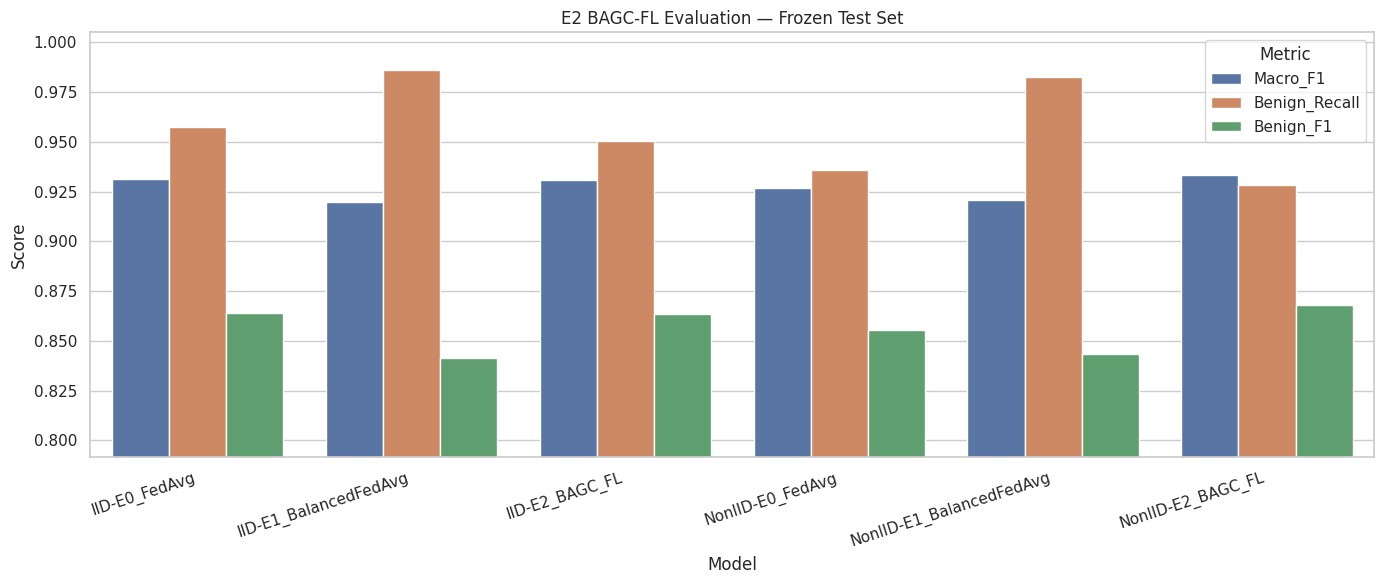

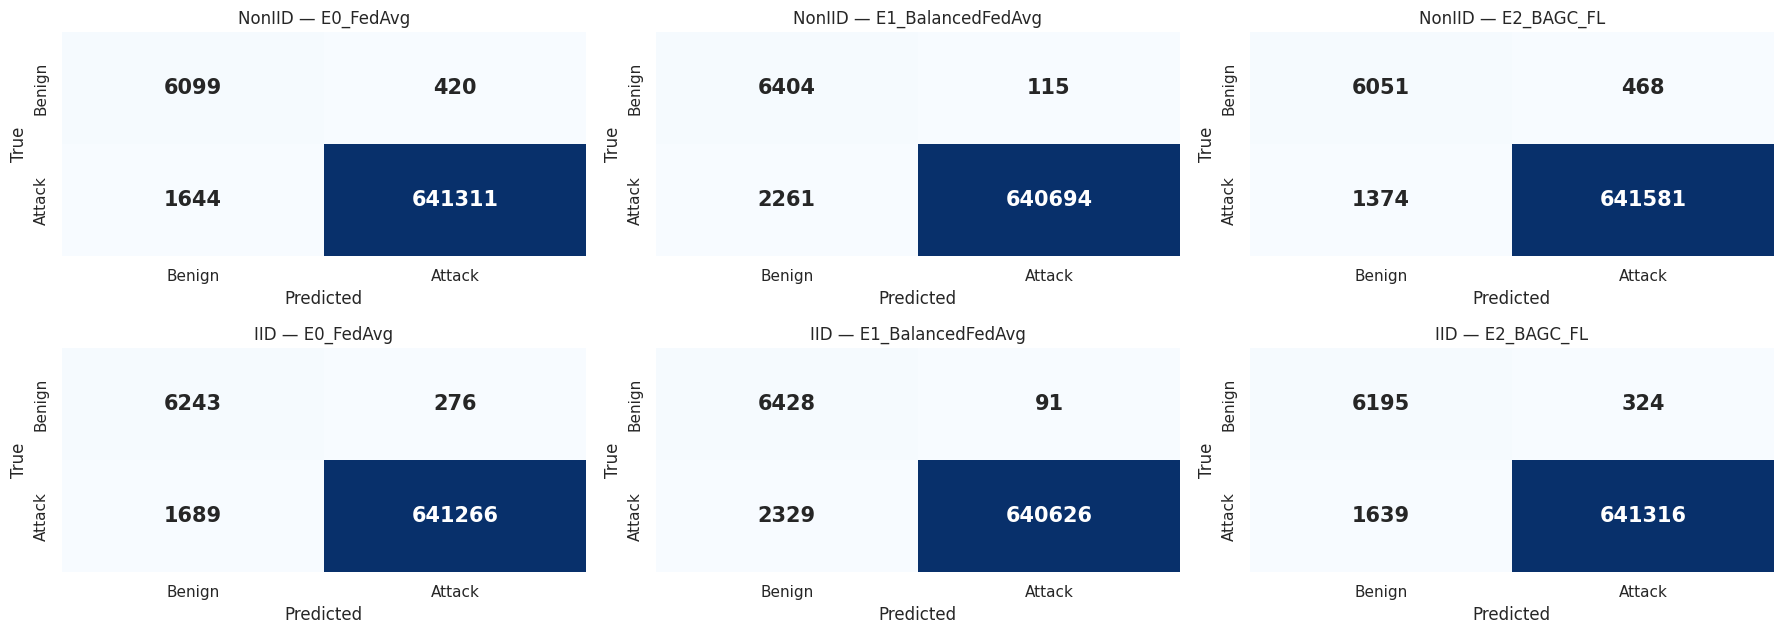

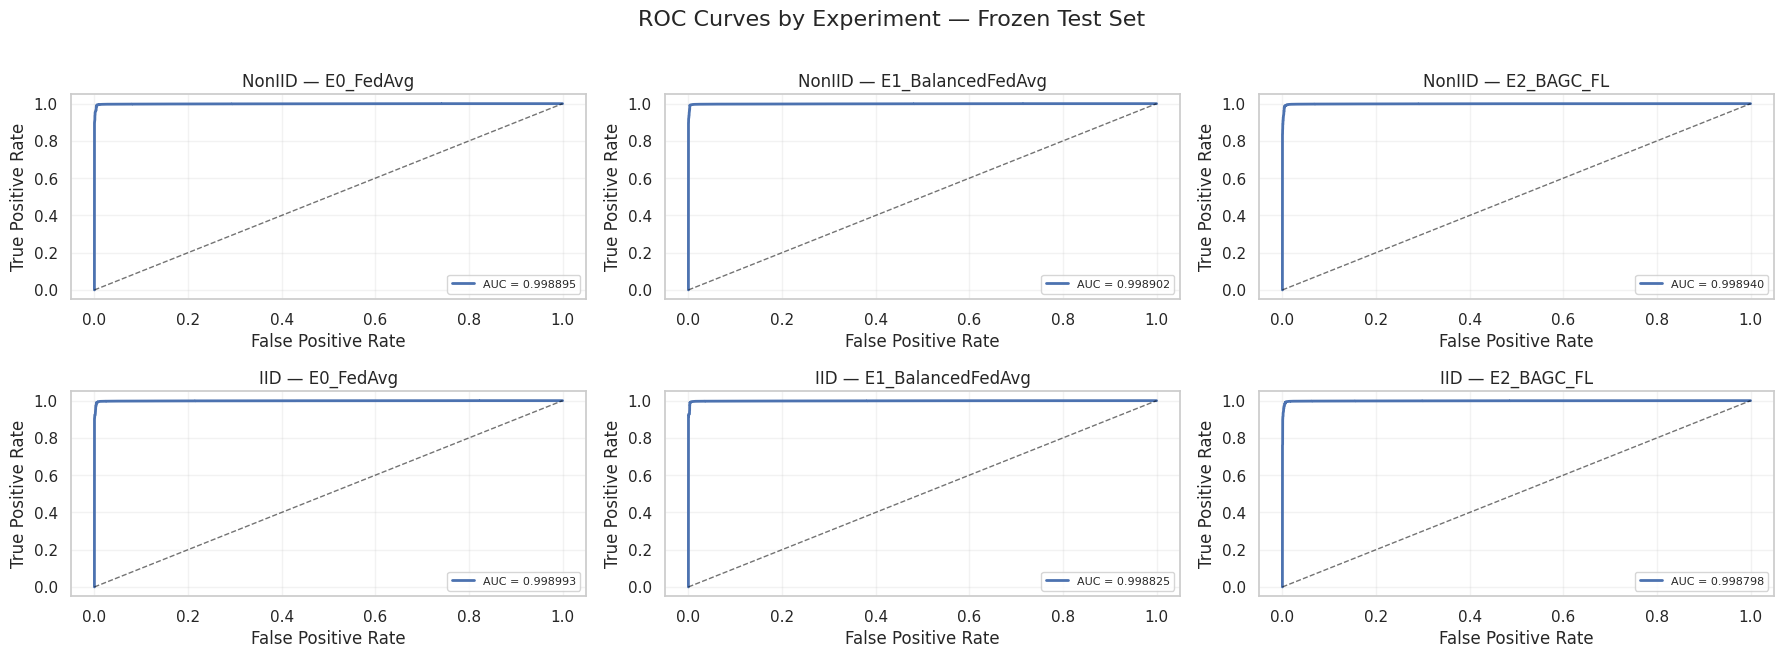

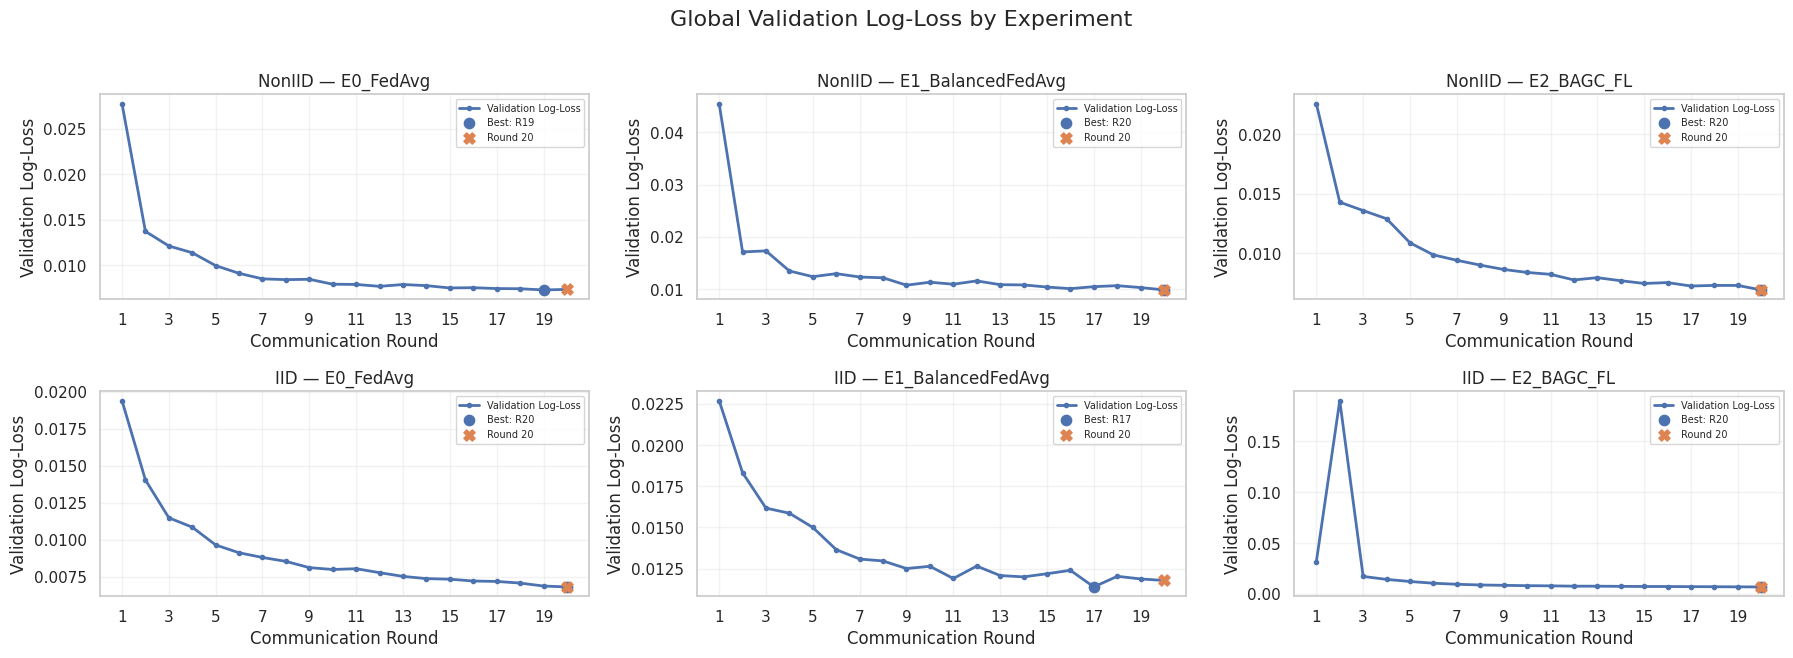

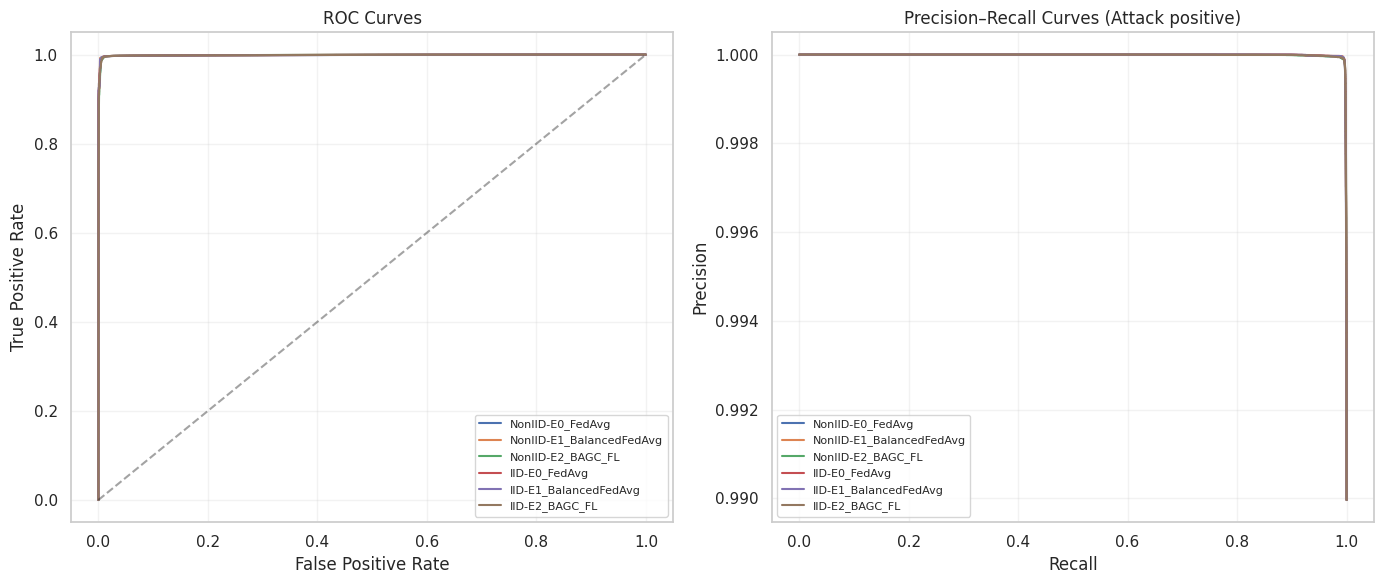

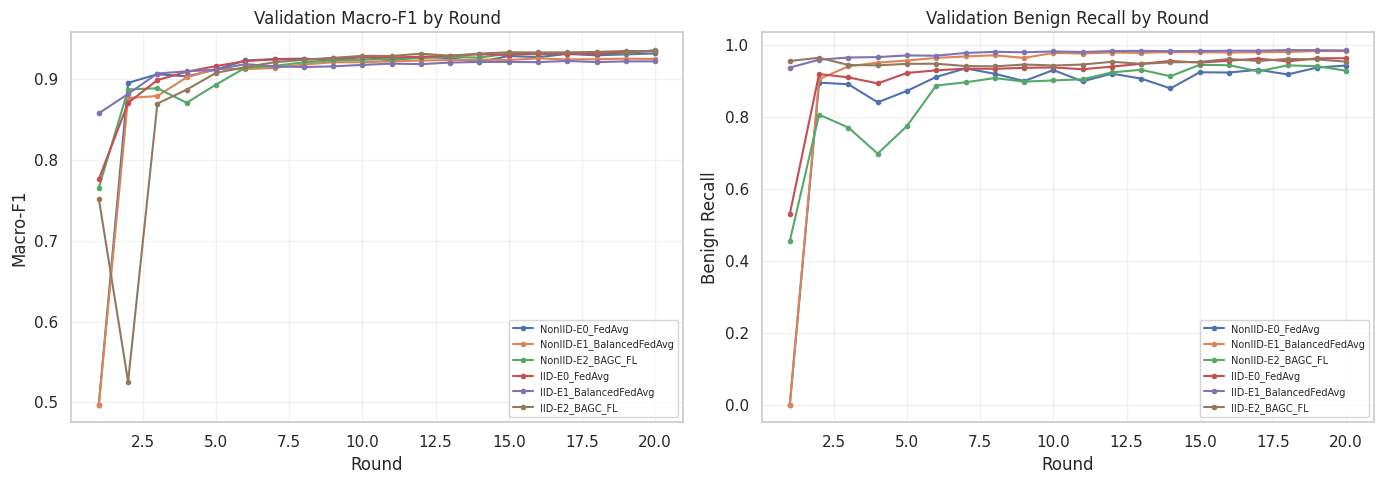

,Partition,Experiment,Accuracy,Macro_F1,Weighted_F1,Benign_Precision,Benign_Recall,Benign_F1,Attack_Precision,Attack_Recall,Attack_F1,ROC_AUC,PR_AUC
0,IID,E0_FedAvg,0.996974,0.931247,0.997121,0.787065,0.957662,0.864023,0.999570,0.997373,0.998470,0.998993,0.999990
1,IID,E1_BalancedFedAvg,0.996274,0.919848,0.996544,0.734041,0.986041,0.841582,0.999858,0.996378,0.998115,0.998825,0.999988
2,IID,E2_BAGC_FL,0.996978,0.930853,0.997114,0.790784,0.950299,0.863234,0.999495,0.997451,0.998472,0.998798,0.999988
3,NonIID,E0_FedAvg,0.996822,0.926837,0.996957,0.787679,0.935573,0.855280,0.999346,0.997443,0.998393,0.998895,0.999989
4,NonIID,E1_BalancedFedAvg,0.996342,0.920834,0.996597,0.739065,0.982359,0.843519,0.999821,0.996483,0.998149,0.998902,0.999989
5,NonIID,E2_BAGC_FL,0.997164,0.933233,0.997255,0.814949,0.928210,0.867900,0.999271,0.997863,0.998567,0.998940,0.999989


Paper-ready results: /content/drive/MyDrive/IoMT_Thesis_2024/FL_BAGC_proposed_method/final_results_e2_proposed/paper_ready_e2_proposed_results.csv
Figures folder     : /content/drive/MyDrive/IoMT_Thesis_2024/FL_BAGC_proposed_method/final_results_e2_proposed/figures


In [11]:
# ================================================================
# CELL 11 — Paper-ready tables and figures
# ================================================================
sns.set_theme(style='whitegrid', context='notebook')

paper_table = final_metrics_df[[
    'Partition', 'Experiment', 'Accuracy', 'Macro_F1', 'Weighted_F1',
    'Benign_Precision', 'Benign_Recall', 'Benign_F1',
    'Attack_Precision', 'Attack_Recall', 'Attack_F1', 'ROC_AUC', 'PR_AUC'
]].copy()
paper_table.to_csv(FINAL_RESULT_OUT / 'paper_ready_e2_proposed_results.csv', index=False)

# Performance bars
long = paper_table.melt(
    id_vars=['Partition', 'Experiment'],
    value_vars=['Macro_F1', 'Benign_Recall', 'Benign_F1'],
    var_name='Metric', value_name='Score'
)
long['Model'] = long['Partition'] + '-' + long['Experiment']
plt.figure(figsize=(14, 6))
sns.barplot(data=long, x='Model', y='Score', hue='Metric', errorbar=None)
plt.ylim(max(0, long['Score'].min()-0.05), 1.005)
plt.title('E2 BAGC-FL Evaluation — Frozen Test Set')
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
plt.savefig(FINAL_FIGURE_OUT / 'test_key_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 6.5))
for ax, (partition, paper_label, storage_id, *_) in zip(axes.flat, FINAL_EXPERIMENT_PLAN):
    pred = prediction_cache[(partition, paper_label)]['predictions']
    cm = confusion_matrix(TEST_LABELS, pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
        annot_kws={'fontsize': 15, 'fontweight': 'bold'}
    )
    ax.set_title(f'{partition} — {paper_label}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticklabels(['Benign', 'Attack']); ax.set_yticklabels(['Benign', 'Attack'])
plt.tight_layout()
plt.savefig(FINAL_FIGURE_OUT / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Individual-style ROC curves in one compact 2×4 paper-ready grid
fig, axes = plt.subplots(2, 3, figsize=(18, 6.5))
for ax, (partition, paper_label, storage_id, *_) in zip(axes.flat, FINAL_EXPERIMENT_PLAN):
    probs = prediction_cache[(partition, paper_label)]['probabilities']
    fpr, tpr, _ = roc_curve(TEST_LABELS, probs)
    auc_value = roc_auc_score(TEST_LABELS, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_value:.6f}')
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='black', alpha=.55)
    ax.set_title(f'{partition} — {paper_label}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=.25)
plt.suptitle('ROC Curves by Experiment — Frozen Test Set', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FINAL_FIGURE_OUT / 'roc_curves_by_experiment.png', dpi=300, bbox_inches='tight')
plt.show()

# Original-FL-style global validation log-loss curves by communication round
fig, axes = plt.subplots(2, 3, figsize=(18, 6.5))
for ax, (partition, paper_label, storage_id, *_) in zip(axes.flat, FINAL_EXPERIMENT_PLAN):
    h = pd.read_csv(EXPERIMENT_OUT / partition / storage_id / 'round_history.csv')
    if len(h) != TOTAL_ROUNDS or 'Final_Val_Loss' not in h.columns:
        raise RuntimeError(f'Invalid log-loss history for {partition}/{storage_id}.')
    best_position = int(h['Final_Val_Loss'].astype(float).to_numpy().argmin())
    best_round = int(h.iloc[best_position]['Round'])
    best_loss = float(h.iloc[best_position]['Final_Val_Loss'])
    final_loss = float(h.iloc[-1]['Final_Val_Loss'])
    ax.plot(
        h['Round'], h['Final_Val_Loss'], marker='o', markersize=3,
        linewidth=2, label='Validation Log-Loss'
    )
    ax.scatter([best_round], [best_loss], s=55, zorder=5, label=f'Best: R{best_round}')
    ax.scatter([TOTAL_ROUNDS], [final_loss], marker='X', s=65, zorder=5, label='Round 20')
    ax.set_title(f'{partition} — {paper_label}')
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Validation Log-Loss')
    ax.set_xticks(range(1, TOTAL_ROUNDS + 1, 2))
    ax.legend(fontsize=7)
    ax.grid(alpha=.25)
plt.suptitle('Global Validation Log-Loss by Experiment', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FINAL_FIGURE_OUT / 'validation_log_loss_by_experiment.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for partition, paper_label, storage_id, *_ in FINAL_EXPERIMENT_PLAN:
    probs = prediction_cache[(partition, paper_label)]['probabilities']
    fpr, tpr, _ = roc_curve(TEST_LABELS, probs)
    precision, recall, _ = precision_recall_curve(TEST_LABELS, probs)
    label = f'{partition}-{paper_label}'
    axes[0].plot(fpr, tpr, label=label)
    axes[1].plot(recall, precision, label=label)
axes[0].plot([0,1],[0,1],'k--',alpha=.4)
axes[0].set(title='ROC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].set(title='Precision–Recall Curves (Attack positive)', xlabel='Recall', ylabel='Precision')
for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig(FINAL_FIGURE_OUT / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Round-level convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for partition, paper_label, storage_id, *_ in FINAL_EXPERIMENT_PLAN:
    h = pd.read_csv(EXPERIMENT_OUT / partition / storage_id / 'round_history.csv')
    label = f'{partition}-{paper_label}'
    axes[0].plot(h['Round'], h['Final_Val_Macro_F1'], marker='o', ms=3, label=label)
    axes[1].plot(h['Round'], h['Final_Val_Benign_Recall'], marker='o', ms=3, label=label)
axes[0].set(title='Validation Macro-F1 by Round', xlabel='Round', ylabel='Macro-F1')
axes[1].set(title='Validation Benign Recall by Round', xlabel='Round', ylabel='Benign Recall')
for ax in axes: ax.legend(fontsize=7); ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig(FINAL_FIGURE_OUT / 'round_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

display(paper_table.style.format(precision=6))
print('Paper-ready results:', FINAL_RESULT_OUT / 'paper_ready_e2_proposed_results.csv')
print('Figures folder     :', FINAL_FIGURE_OUT)


## Explainability of the proposed E2 BAGC-FL model

This section generates post-hoc **SHAP** global explanations and **LIME** local
explanations for the proposed E2 model under both Non-IID and IID partitions.
The background/reference observations come only from the frozen validation
split. A small stratified subset of the untouched test set is explained only
after final evaluation; it is not used for training, threshold selection, model
selection, or feature selection.

SHAP reports the overall magnitude and direction of feature contributions.
LIME explains two reproducibly selected, correctly classified examples per
partition: one Benign and one Attack. These are approximate post-hoc
explanations and should not be described as causal effects.


Installing lime ...
Computing Kernel SHAP: NonIID/E2_BAGC_FL ...


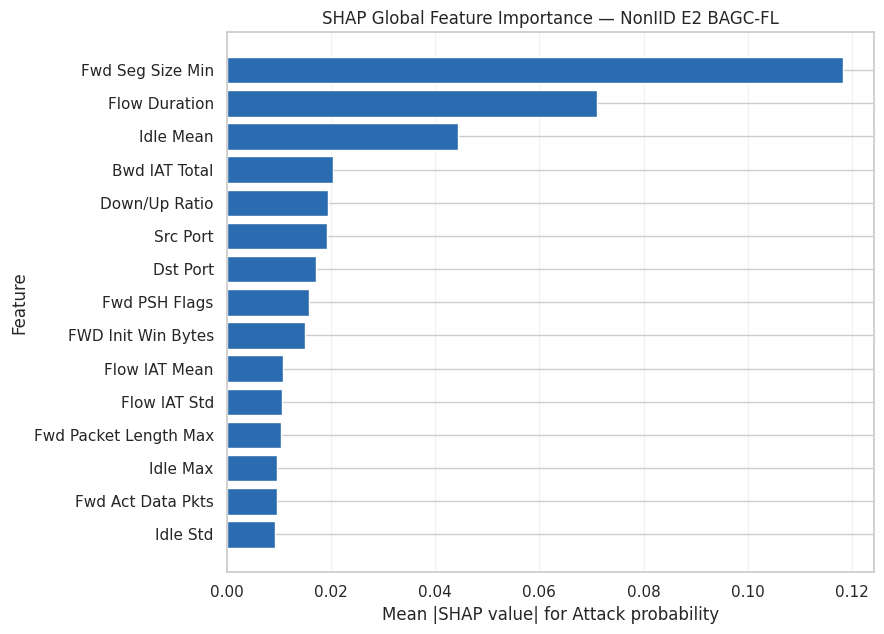

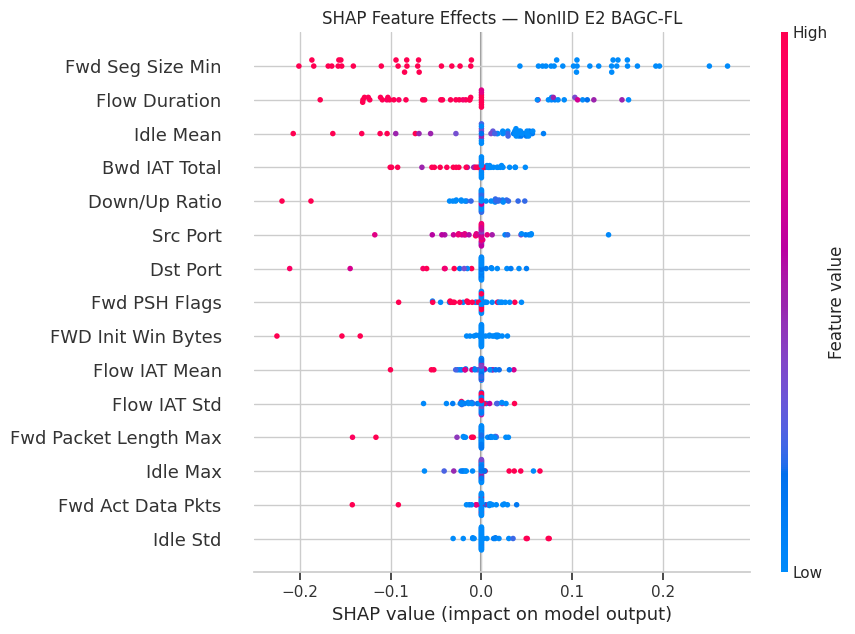

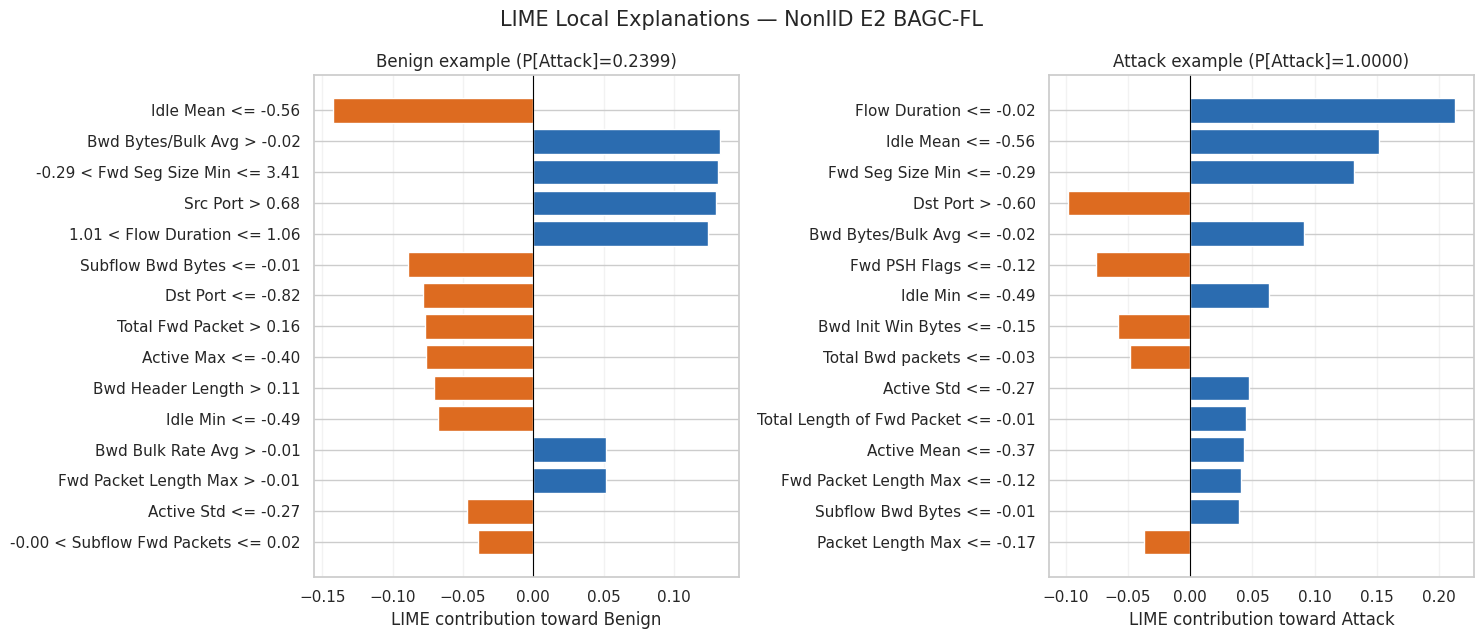

Computing Kernel SHAP: IID/E2_BAGC_FL ...


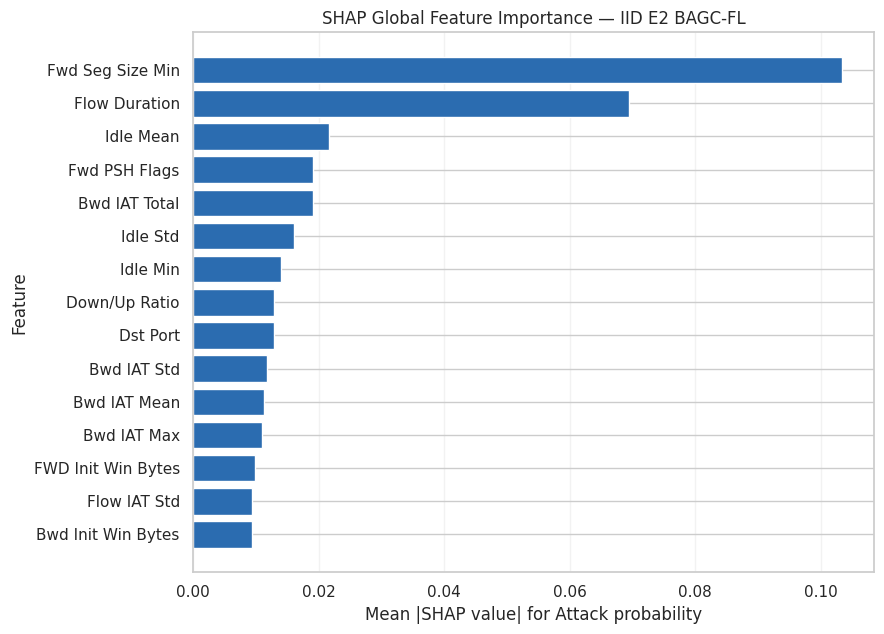

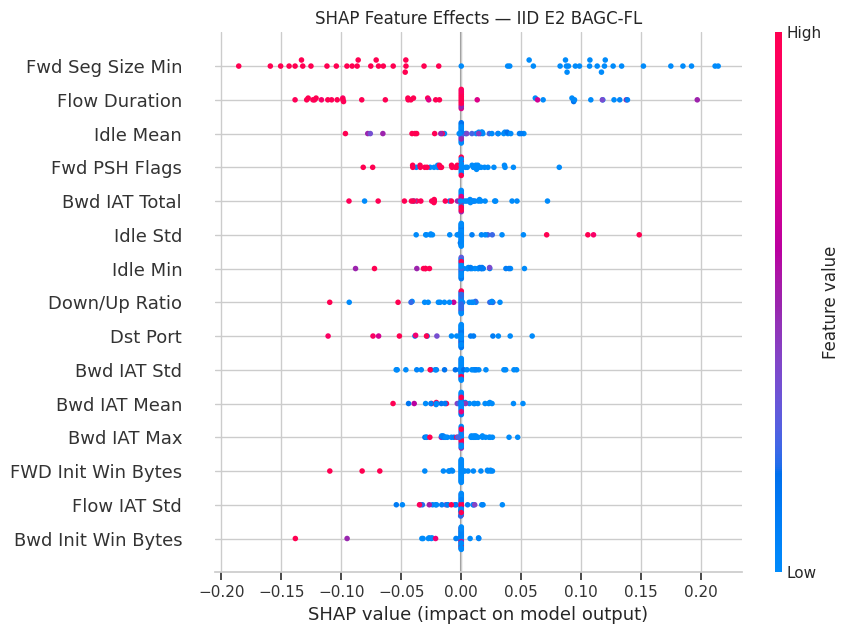

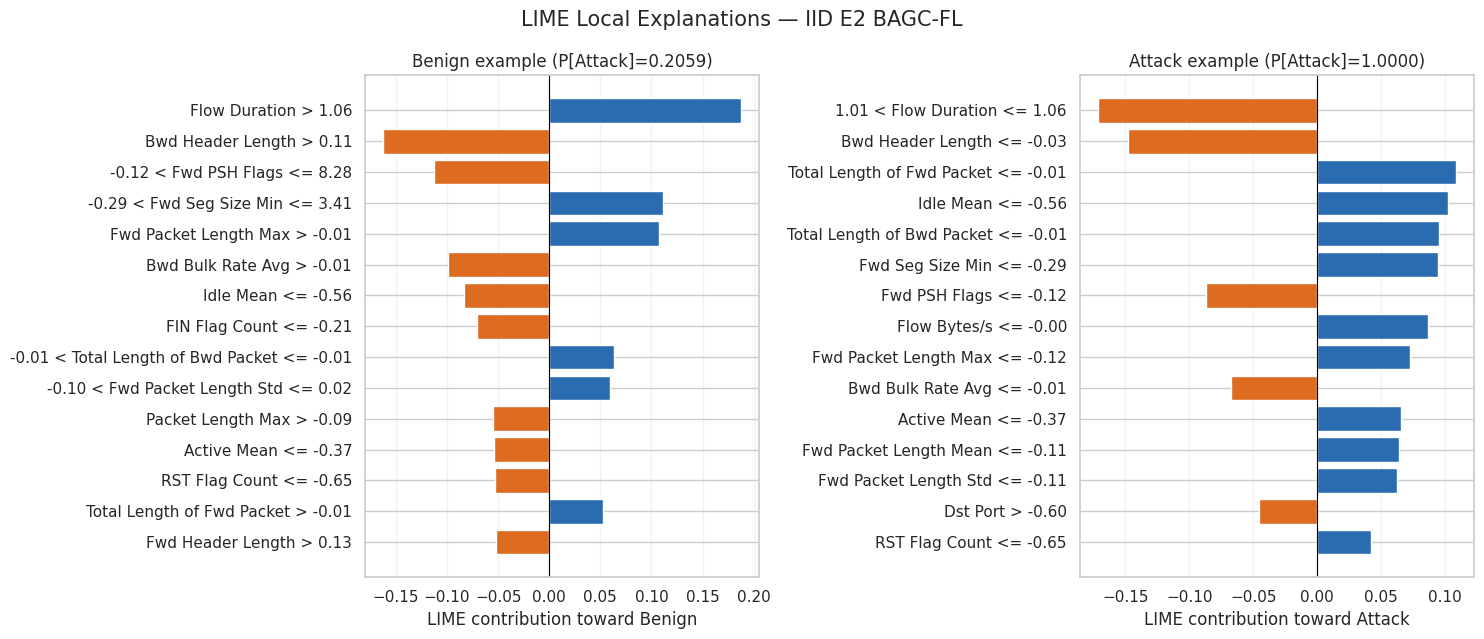

✅ SHAP and LIME figures saved to: /content/drive/MyDrive/IoMT_Thesis_2024/FL_BAGC_proposed_method/final_results_e2_proposed/explainability
Interpretation reminder: SHAP/LIME are approximate associations, not causal effects.


In [12]:
# ================================================================
# CELL 12A — SHAP and LIME explainability for proposed E2 BAGC-FL
# ================================================================
import importlib.util
import subprocess
import sys

for package_name in ('shap', 'lime'):
    if importlib.util.find_spec(package_name) is None:
        print(f'Installing {package_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

import shap
from lime.lime_tabular import LimeTabularExplainer

XAI_SEED = RANDOM_SEED
XAI_TOP_FEATURES = 15
SHAP_BACKGROUND_PER_CLASS = 20
SHAP_EXPLAIN_PER_CLASS = 25
SHAP_NSAMPLES = 220
LIME_NUM_SAMPLES = 2500
XAI_OUT = FINAL_RESULT_OUT / 'explainability'
XAI_OUT.mkdir(parents=True, exist_ok=True)


def stratified_indices(labels, per_class, seed):
    """Deterministically sample the same maximum number from each class."""
    labels = np.asarray(labels, dtype=np.int8)
    rng = np.random.default_rng(seed)
    selected = []
    for class_id in (0, 1):
        available = np.flatnonzero(labels == class_id)
        if len(available) == 0:
            raise RuntimeError(f'No class {class_id} observations available for XAI.')
        take = min(int(per_class), len(available))
        selected.append(rng.choice(available, size=take, replace=False))
    return np.concatenate(selected).astype(np.int64)


def predict_attack_probability(model, x_2d, batch_size=512):
    """SHAP-compatible predictor returning P(Attack) for standardized 2-D data."""
    x_2d = np.asarray(x_2d, dtype=np.float32)
    output = np.empty(len(x_2d), dtype=np.float64)
    for start in range(0, len(x_2d), batch_size):
        end = min(start + batch_size, len(x_2d))
        xb = x_2d[start:end, :, np.newaxis]
        output[start:end] = model(xb, training=False).numpy().reshape(-1)
    return output


def normalize_kernel_shap_values(values, rows, columns):
    """Normalize SHAP outputs across compatible SHAP package versions."""
    if isinstance(values, list):
        values = values[-1]
    values = np.asarray(values)
    if values.ndim == 3:
        values = values[..., -1]
    values = np.squeeze(values)
    if values.shape == (columns, rows):
        values = values.T
    if values.shape != (rows, columns):
        raise RuntimeError(f'Unexpected SHAP value shape: {values.shape}')
    return values.astype(np.float64, copy=False)


def representative_correct_index(labels, probabilities, class_id):
    """Pick a correct example closest to its class median confidence."""
    labels = np.asarray(labels, dtype=np.int8)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    predictions = (probabilities >= 0.5).astype(np.int8)
    candidates = np.flatnonzero((labels == class_id) & (predictions == class_id))
    if len(candidates) == 0:
        raise RuntimeError(f'No correctly classified class {class_id} example for LIME.')
    class_probs = probabilities[candidates]
    target = np.median(class_probs)
    return int(candidates[np.argmin(np.abs(class_probs - target))])


validation_labels_xai = np.asarray(y_train[validation_indices], dtype=np.int8)
background_local = stratified_indices(
    validation_labels_xai, SHAP_BACKGROUND_PER_CLASS, XAI_SEED
)
background_indices = validation_indices[background_local]
xai_background = np.asarray(X_train[background_indices], dtype=np.float32)

test_explain_indices = stratified_indices(
    TEST_LABELS, SHAP_EXPLAIN_PER_CLASS, XAI_SEED + 1
)
xai_test = np.asarray(X_test[test_explain_indices], dtype=np.float32)
xai_test_labels = TEST_LABELS[test_explain_indices]

xai_manifest = {
    'random_seed': int(XAI_SEED),
    'background_source': 'frozen validation split',
    'background_rows': int(len(xai_background)),
    'explained_source': 'post-evaluation stratified frozen-test subset',
    'explained_rows': int(len(xai_test)),
    'shap_method': 'model-agnostic Kernel SHAP',
    'shap_nsamples': int(SHAP_NSAMPLES),
    'lime_num_samples': int(LIME_NUM_SAMPLES),
    'top_features_plotted': int(XAI_TOP_FEATURES),
    'threshold': 0.5,
    'test_used_for_training_or_selection': False,
}

for partition, partition_seed in [('NonIID', XAI_SEED + 10), ('IID', XAI_SEED + 20)]:
    storage_id = 'E2_AnchorFedAvg'
    model_path = EXPERIMENT_OUT / partition / storage_id / 'round20_final.weights.h5'
    if not model_path.exists():
        raise FileNotFoundError(f'Missing proposed E2 model: {model_path}')

    tf.keras.backend.clear_session()
    model = build_binary_model()
    model.load_weights(model_path)

    def attack_predictor(data):
        return predict_attack_probability(model, data)

    # ------------------------- global SHAP -------------------------
    print(f'Computing Kernel SHAP: {partition}/E2_BAGC_FL ...')
    kernel_explainer = shap.KernelExplainer(attack_predictor, xai_background)
    try:
        raw_shap_values = kernel_explainer.shap_values(
            xai_test, nsamples=SHAP_NSAMPLES, silent=True,
            l1_reg=f'num_features({min(25, NUM_FEATURES)})'
        )
    except TypeError:
        raw_shap_values = kernel_explainer.shap_values(
            xai_test, nsamples=SHAP_NSAMPLES,
            l1_reg=f'num_features({min(25, NUM_FEATURES)})'
        )
    shap_values = normalize_kernel_shap_values(
        raw_shap_values, len(xai_test), NUM_FEATURES
    )

    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    importance_order = np.argsort(mean_abs_shap)[::-1]
    importance_df = pd.DataFrame({
        'Feature': np.asarray(feature_names)[importance_order],
        'Mean_Absolute_SHAP': mean_abs_shap[importance_order],
        'Rank': np.arange(1, NUM_FEATURES + 1),
        'Partition': partition,
    })
    importance_df.to_csv(
        XAI_OUT / f'{partition}_E2_BAGC_FL_shap_importance.csv', index=False
    )

    top = importance_df.head(XAI_TOP_FEATURES).iloc[::-1]
    plt.figure(figsize=(9, 6.5))
    plt.barh(top['Feature'], top['Mean_Absolute_SHAP'], color='#2B6CB0')
    plt.xlabel('Mean |SHAP value| for Attack probability')
    plt.ylabel('Feature')
    plt.title(f'SHAP Global Feature Importance — {partition} E2 BAGC-FL')
    plt.grid(axis='x', alpha=.25)
    plt.tight_layout()
    plt.savefig(
        XAI_OUT / f'{partition}_E2_BAGC_FL_shap_global_bar.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    shap.summary_plot(
        shap_values, xai_test, feature_names=feature_names,
        max_display=XAI_TOP_FEATURES, show=False, plot_size=(9, 6.5)
    )
    plt.title(f'SHAP Feature Effects — {partition} E2 BAGC-FL')
    plt.tight_layout()
    plt.savefig(
        XAI_OUT / f'{partition}_E2_BAGC_FL_shap_beeswarm.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    # -------------------------- local LIME -------------------------
    lime_explainer = LimeTabularExplainer(
        training_data=xai_background,
        feature_names=feature_names,
        class_names=['Benign', 'Attack'],
        mode='classification',
        discretize_continuous=True,
        random_state=partition_seed,
    )

    def lime_predictor(data):
        attack_probability = attack_predictor(data)
        return np.column_stack([1.0 - attack_probability, attack_probability])

    all_test_probabilities = prediction_cache[(partition, 'E2_BAGC_FL')]['probabilities']
    lime_records = []
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
    for ax, class_id, class_name in zip(axes, (0, 1), ('Benign', 'Attack')):
        test_index = representative_correct_index(
            TEST_LABELS, all_test_probabilities, class_id
        )
        instance = np.asarray(X_test[test_index], dtype=np.float32)
        explanation = lime_explainer.explain_instance(
            instance,
            lime_predictor,
            labels=(class_id,),
            num_features=XAI_TOP_FEATURES,
            num_samples=LIME_NUM_SAMPLES,
        )
        pairs = explanation.as_list(label=class_id)
        conditions = [pair[0] for pair in pairs][::-1]
        weights = np.asarray([pair[1] for pair in pairs][::-1], dtype=float)
        colors = np.where(weights >= 0, '#2B6CB0', '#DD6B20')
        ax.barh(conditions, weights, color=colors)
        ax.axvline(0, color='black', linewidth=.8)
        attack_probability = float(all_test_probabilities[test_index])
        ax.set_title(
            f'{class_name} example (P[Attack]={attack_probability:.4f})'
        )
        ax.set_xlabel(f'LIME contribution toward {class_name}')
        ax.grid(axis='x', alpha=.25)
        for condition, weight in pairs:
            lime_records.append({
                'Partition': partition,
                'Explained_Class': class_name,
                'Test_Index': test_index,
                'Attack_Probability': attack_probability,
                'Feature_Condition': condition,
                'LIME_Weight': float(weight),
            })
    fig.suptitle(
        f'LIME Local Explanations — {partition} E2 BAGC-FL', fontsize=15
    )
    plt.tight_layout()
    plt.savefig(
        XAI_OUT / f'{partition}_E2_BAGC_FL_lime_local.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()
    pd.DataFrame(lime_records).to_csv(
        XAI_OUT / f'{partition}_E2_BAGC_FL_lime_explanations.csv', index=False
    )

    del model, kernel_explainer, raw_shap_values, shap_values
    gc.collect()

atomic_json(XAI_OUT / 'xai_method_manifest.json', xai_manifest)
print('✅ SHAP and LIME figures saved to:', XAI_OUT)
print('Interpretation reminder: SHAP/LIME are approximate associations, not causal effects.')


In [13]:
# ================================================================
# CELL 12 — Final E2 BAGC-FL methodological and artifact audit
# ================================================================
audit_rows = []
for partition, paper_label, storage_id, weighted, correction, safeguard in FINAL_EXPERIMENT_PLAN:
    exp_dir = EXPERIMENT_OUT / partition / storage_id
    history = pd.read_csv(exp_dir / 'round_history.csv')
    config = json.load(open(exp_dir / 'config.json'))
    checks = {
        'Final model exists': (exp_dir / 'round20_final.weights.h5').exists(),
        'Exactly 20 history rows': len(history) == TOTAL_ROUNDS,
        'Rounds exactly 1–20': history['Round'].astype(int).tolist() == list(range(1, TOTAL_ROUNDS+1)),
        'Common initialization': config['initial_weight_sha256'] == initial_hash,
        'Correct partition hash': config['partition_sha256'] == sha256_array(PARTITIONS[partition]),
        'Same clients/round': config['clients_per_round'] == CLIENTS_PER_ROUND,
        'Same local epochs': config['local_epochs'] == LOCAL_EPOCHS,
        'Same batch size': config['batch_size'] == LOCAL_BATCH_SIZE,
        'Same learning rate': config['learning_rate'] == LEARNING_RATE,
        'Correct weighted-BCE component': config['weighted_bce'] == bool(weighted),
        'Correct anchor-correction component': config['anchor_correction'] == bool(correction),
        'Correct safeguard component': config['validation_safeguard'] == bool(safeguard),
        'No rolling round checkpoint remains': not any(exp_dir.glob('round_*.weights.h5')),
        'No partial-client checkpoint remains': not (exp_dir / 'partial_round_clients.npz').exists(),
        'Prediction cache exists': (exp_dir / 'final_test_predictions.npz').exists(),
        'Final metrics exist': (exp_dir / 'final_test_metrics.csv').exists(),
    }
    audit_rows.append({
        'Partition': partition, 'Experiment': paper_label, 'Storage_ID': storage_id,
        'All_Checks_Passed': bool(all(checks.values())),
        'Failed_Checks': '; '.join(k for k, v in checks.items() if not v),
        'Accepted_Rounds': int(history['Accepted'].sum()),
        'Conflict_Rounds': int(history['Benign_Conflict'].sum()),
        'Total_Time_Minutes': float(history['Round_Time_sec'].sum()/60),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(FINAL_RESULT_OUT / 'final_methodological_audit.csv', index=False)
display(audit_df)
if not audit_df['All_Checks_Passed'].all():
    raise RuntimeError('Final audit failed. Review final_methodological_audit.csv.')
if final_metrics_df['Test_Samples'].nunique() != 1 or int(final_metrics_df['Test_Samples'].iloc[0]) != TEST_ROWS:
    raise RuntimeError('Experiments were not evaluated on the identical frozen test set.')

best_noniid = final_metrics_df.query("Partition == 'NonIID'").sort_values(
    ['Macro_F1', 'Benign_F1'], ascending=False
).iloc[0]
bagc_noniid = final_metrics_df.query(
    "Partition == 'NonIID' and Experiment == 'E2_BAGC_FL'"
).iloc[0]
e0_noniid = final_metrics_df.query(
    "Partition == 'NonIID' and Experiment == 'E0_FedAvg'"
).iloc[0]
e1_noniid = final_metrics_df.query(
    "Partition == 'NonIID' and Experiment == 'E1_BalancedFedAvg'"
).iloc[0]

summary = {
    'presentation_version': FINAL_PRESENTATION_VERSION,
    'underlying_training_version': METHOD_VERSION,
    'proposed_method': 'E2_BAGC_FL',
    'proposed_method_storage_id': 'E2_AnchorFedAvg',
    'proposed_components': ['Binary cross-entropy', 'FedAvg', 'Benign-anchor gradient correction'],
    'all_audits_passed': True,
    'best_noniid_experiment_by_macro_f1': best_noniid['Experiment'],
    'best_noniid_macro_f1': float(best_noniid['Macro_F1']),
    'bagc_minus_e0_noniid_macro_f1': float(bagc_noniid['Macro_F1']-e0_noniid['Macro_F1']),
    'bagc_minus_e1_noniid_macro_f1': float(bagc_noniid['Macro_F1']-e1_noniid['Macro_F1']),
    'test_samples': TEST_ROWS,
    'test_used_during_training': False,
    'decision_threshold': 0.50,
    'server_anchor_assumption': 'Shared validation benign subset is available to the server',
    'novelty_claim_status': 'Requires literature-supported wording; experimental evidence alone does not establish novelty',
}
atomic_json(FINAL_RESULT_OUT / 'e2_bagc_fl_completion_summary.json', summary)

print('=' * 92)
print('✅ FINAL E2 BAGC-FL STUDY IS COMPLETE')
print('=' * 92)
print('All six E0–E2 artifacts passed the final audit.')
print('Best Non-IID model by Macro-F1:', summary['best_noniid_experiment_by_macro_f1'])
print('BAGC-FL − E0 Non-IID Macro-F1:', f"{summary['bagc_minus_e0_noniid_macro_f1']:+.6f}")
print('BAGC-FL − E1 Non-IID Macro-F1:', f"{summary['bagc_minus_e1_noniid_macro_f1']:+.6f}")
print('Results folder:', FINAL_RESULT_OUT)
print('\nInterpret BAGC-FL claims using the paired confidence intervals and Holm-corrected tests.')


,Partition,Experiment,Storage_ID,All_Checks_Passed,Failed_Checks,Accepted_Rounds,Conflict_Rounds,Total_Time_Minutes
0,NonIID,E0_FedAvg,E0_FedAvg,True,,20,0,621.371932
1,NonIID,E1_BalancedFedAvg,E1_BalancedFedAvg,True,,20,0,23.529319
2,NonIID,E2_BAGC_FL,E2_AnchorFedAvg,True,,20,5,25.942406
3,IID,E0_FedAvg,E0_FedAvg,True,,20,0,28.908832
4,IID,E1_BalancedFedAvg,E1_BalancedFedAvg,True,,20,0,226.282666
5,IID,E2_BAGC_FL,E2_AnchorFedAvg,True,,20,12,25.141398


✅ FINAL E2 BAGC-FL STUDY IS COMPLETE
All six E0–E2 artifacts passed the final audit.
Best Non-IID model by Macro-F1: E2_BAGC_FL
BAGC-FL − E0 Non-IID Macro-F1: +0.006397
BAGC-FL − E1 Non-IID Macro-F1: +0.012399
Results folder: /content/drive/MyDrive/IoMT_Thesis_2024/FL_BAGC_proposed_method/final_results_e2_proposed

Interpret BAGC-FL claims using the paired confidence intervals and Holm-corrected tests.


## Methodological note for the thesis/paper

The final proposed method is **E2 BAGC-FL**: standard binary cross-entropy,
FedAvg, and server-side Benign-Anchor Gradient Correction. The Benign anchor is
drawn from the shared validation split, so describe it as a **trusted auxiliary
server validation anchor**. Do not claim that no server-side reference data is
required. The final test set remains untouched until the evaluation cell.

The internal artifact name `E2_AnchorFedAvg` is retained for reproducibility;
`E2_BAGC_FL` is only the paper-facing name. The original experimental notebook
and its artifacts remain preserved separately. A final novelty claim must cite
related work on federated class imbalance, trusted/reference gradients,
gradient correction/projection, and federated intrusion detection.
